In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.stats import norm
import matplotlib

import jax.numpy as jnp
from jax import config, random
import numpyro, jax
import numpyro.distributions as dist

from jnkepler.jaxttv import JaxTTV
from jnkepler.jaxttv import ttv_default_parameter_bounds, ttv_optim_curve_fit, scale_pdic
import corner
import pickle
import dill
import os
import pandas as pd

In [2]:
TESS_offset = 2457000

# Load data

In [3]:
# file_name = '1339_jnkep_initial_fit_data.pkl'
# file_name = '1339_jnkep_initial_fit_data_hessian_tree-11_accept-90_emax-0.5.pkl'
# file_name = '1339_jnkep_initial_fit_data_hessian_tree-11_accept-95_emax-0.5_RV.pkl'

# file_name= '1339_jnkep_initial_fit_data_hessian_tree-11_accept-95_emax-0.5.pkl'
file_name = 'mcmc_runs/1339_jnkep_initial_fit_data_hessian_tree-11_accept-95_emax-0.5_infl_err6.pkl'

with open(file_name, 'rb') as f:
    data = pickle.load(f)

popt = data['popt']
param_bounds = data['param_bounds']
jttv = data['jttv']

In [4]:

# file_name = '1339_jnkep_fit_1339-2000burn-4000step.pkl'
# file_name = '1339_jnkep_fit_1339-2000burn-2000step-emax0.5.pkl'
# file_name = '1339_jnkep_nburn-1000_nsteps-1000_hessian_tree-11_accept-90_emax-0.5.pkl'
#file_name = '1339_jnkep_nburn-1000_nsteps-1000_hessian_tree-11_accept-95_emax-0.5_RV.pkl'
# file_name = "1339_jnkep_fit_fullls.pkl"

# file_name = '1339_jnkep_nburn-1000_nsteps-1000_hessian_tree-11_accept-95_emax-0.5.pkl'
file_name = 'mcmc_runs/1339_jnkep_nburn-1000_nsteps-1000_hessian_tree-11_accept-95_emax-0.5_infl_err6.pkl'

working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")

file_path = os.path.join(data_dir, file_name)

In [5]:
with open(file_name, "rb") as f:
    mcmc = dill.load(f)
mcmc.print_summary()



                      mean       std    median      5.0%     95.0%     n_eff     r_hat
 ecosw_scaled[0]      0.42      0.09      0.44      0.28      0.52     43.49      1.11
 ecosw_scaled[1]      0.43      0.08      0.46      0.31      0.52     43.92      1.11
 esinw_scaled[0]      0.48      0.07      0.50      0.35      0.57    207.79      1.05
 esinw_scaled[1]      0.48      0.06      0.50      0.38      0.56    206.88      1.05
period_scaled[0]      0.50      0.00      0.50      0.50      0.50     48.02      1.10
period_scaled[1]      0.50      0.00      0.50      0.50      0.50    281.11      1.02
 pmass_scaled[0]      0.02      0.00      0.02      0.01      0.03    143.77      1.06
 pmass_scaled[1]      0.01      0.00      0.01      0.01      0.02     76.66      1.08
   tic_scaled[0]      0.48      0.01      0.48      0.47      0.49     32.08      1.14
   tic_scaled[1]      0.52      0.02      0.52      0.48      0.55    195.05      1.04

Number of divergences: 4


In [6]:
# Posterior samples
posterior_samples = mcmc.get_samples()

# Shape of samples
print({k: v.shape for k, v in posterior_samples.items()})


{'ecc': (8000, 2), 'ecosw': (8000, 2), 'ecosw_scaled': (8000, 2), 'ediff': (8000,), 'esinw': (8000, 2), 'esinw_scaled': (8000, 2), 'period': (8000, 2), 'period_scaled': (8000, 2), 'pmass': (8000, 2), 'pmass_scaled': (8000, 2), 'tcmodel': (8000, 39), 'tic': (8000, 2), 'tic_scaled': (8000, 2)}


# Plot models drawn from posteriors 

In [7]:
samples = mcmc.get_samples()

In [8]:
means, stds = jttv.sample_means_and_stds(samples, truncate=False)

/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/jnkepler/jaxttv/jaxttv.py:523: UserWarning: using t0 and P from a linear fit to the observed transit times.
  warnings.warn(


<Figure size 1920x1440 with 0 Axes>

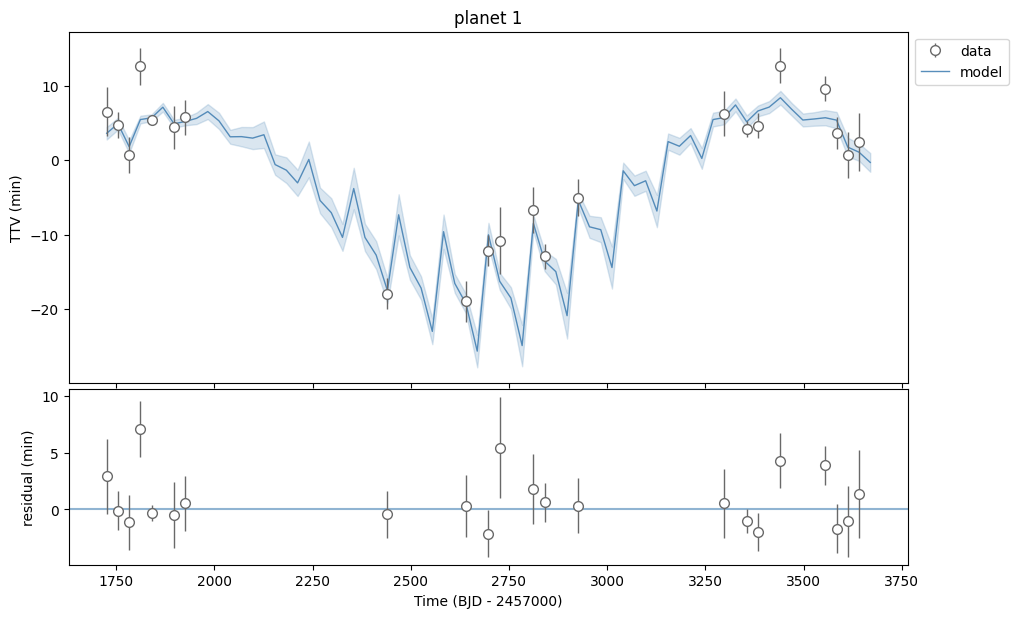

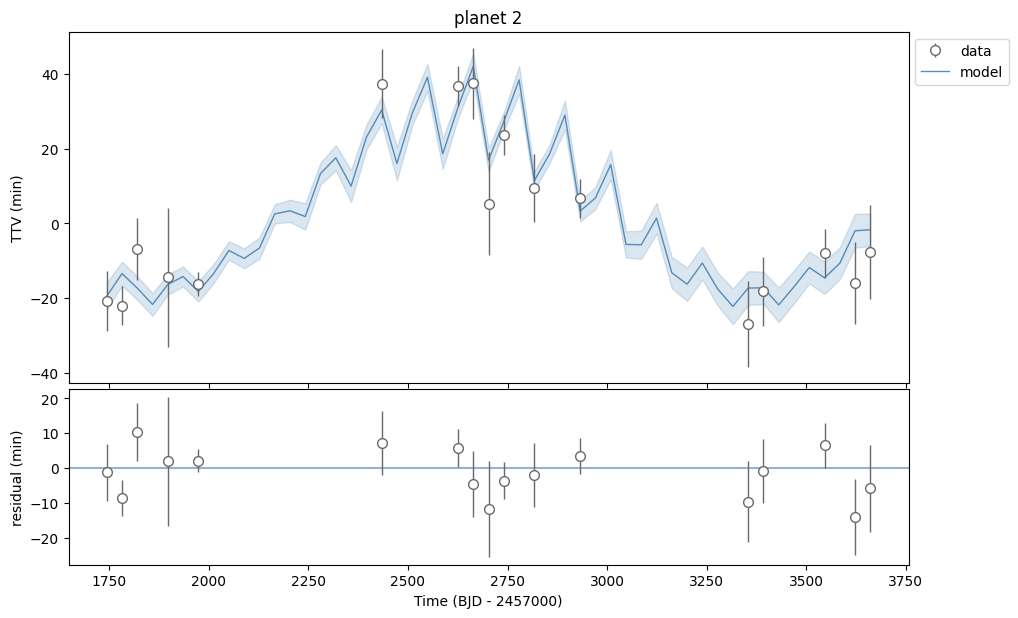

<Figure size 1920x1440 with 0 Axes>

In [9]:

jttv.plot_model(means, tcmodelunclist=stds, xlabel=f'Time (BJD - {TESS_offset})')
plt.figure(dpi=300) 

# Trace and corner plots

In [10]:
sample_keys = ["ecosw", "esinw", "pmass", "period", "tic"] # uniform mass prior

In [11]:
import arviz as az
# idata = az.from_numpyro(mcmc)
samples_sorted = mcmc.get_samples(group_by_chain=True)
idata = az.from_dict(posterior=samples_sorted)

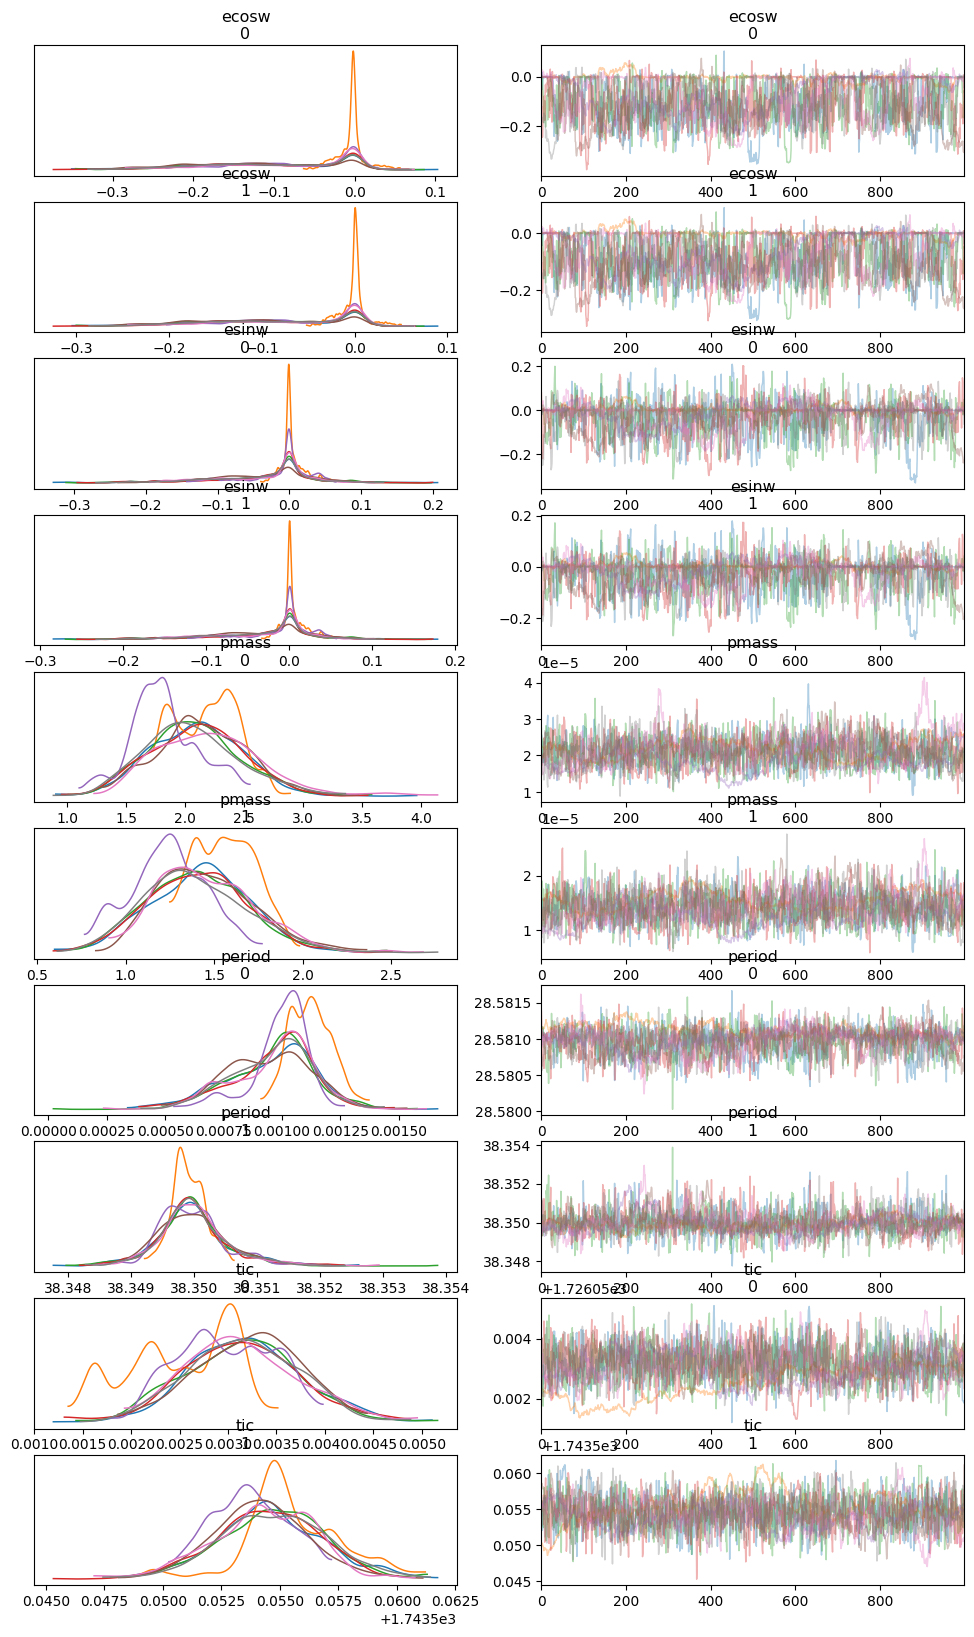

<Figure size 1920x1440 with 0 Axes>

In [12]:
# import arviz as az
# idata = az.from_numpyro(mcmc)
# fig = az.plot_trace(mcmc, var_names=sample_keys, compact=False)
fig = az.plot_trace(idata, var_names=sample_keys, compact=False)
plt.figure(dpi=300) 
plt.tight_layout(pad=0.2)

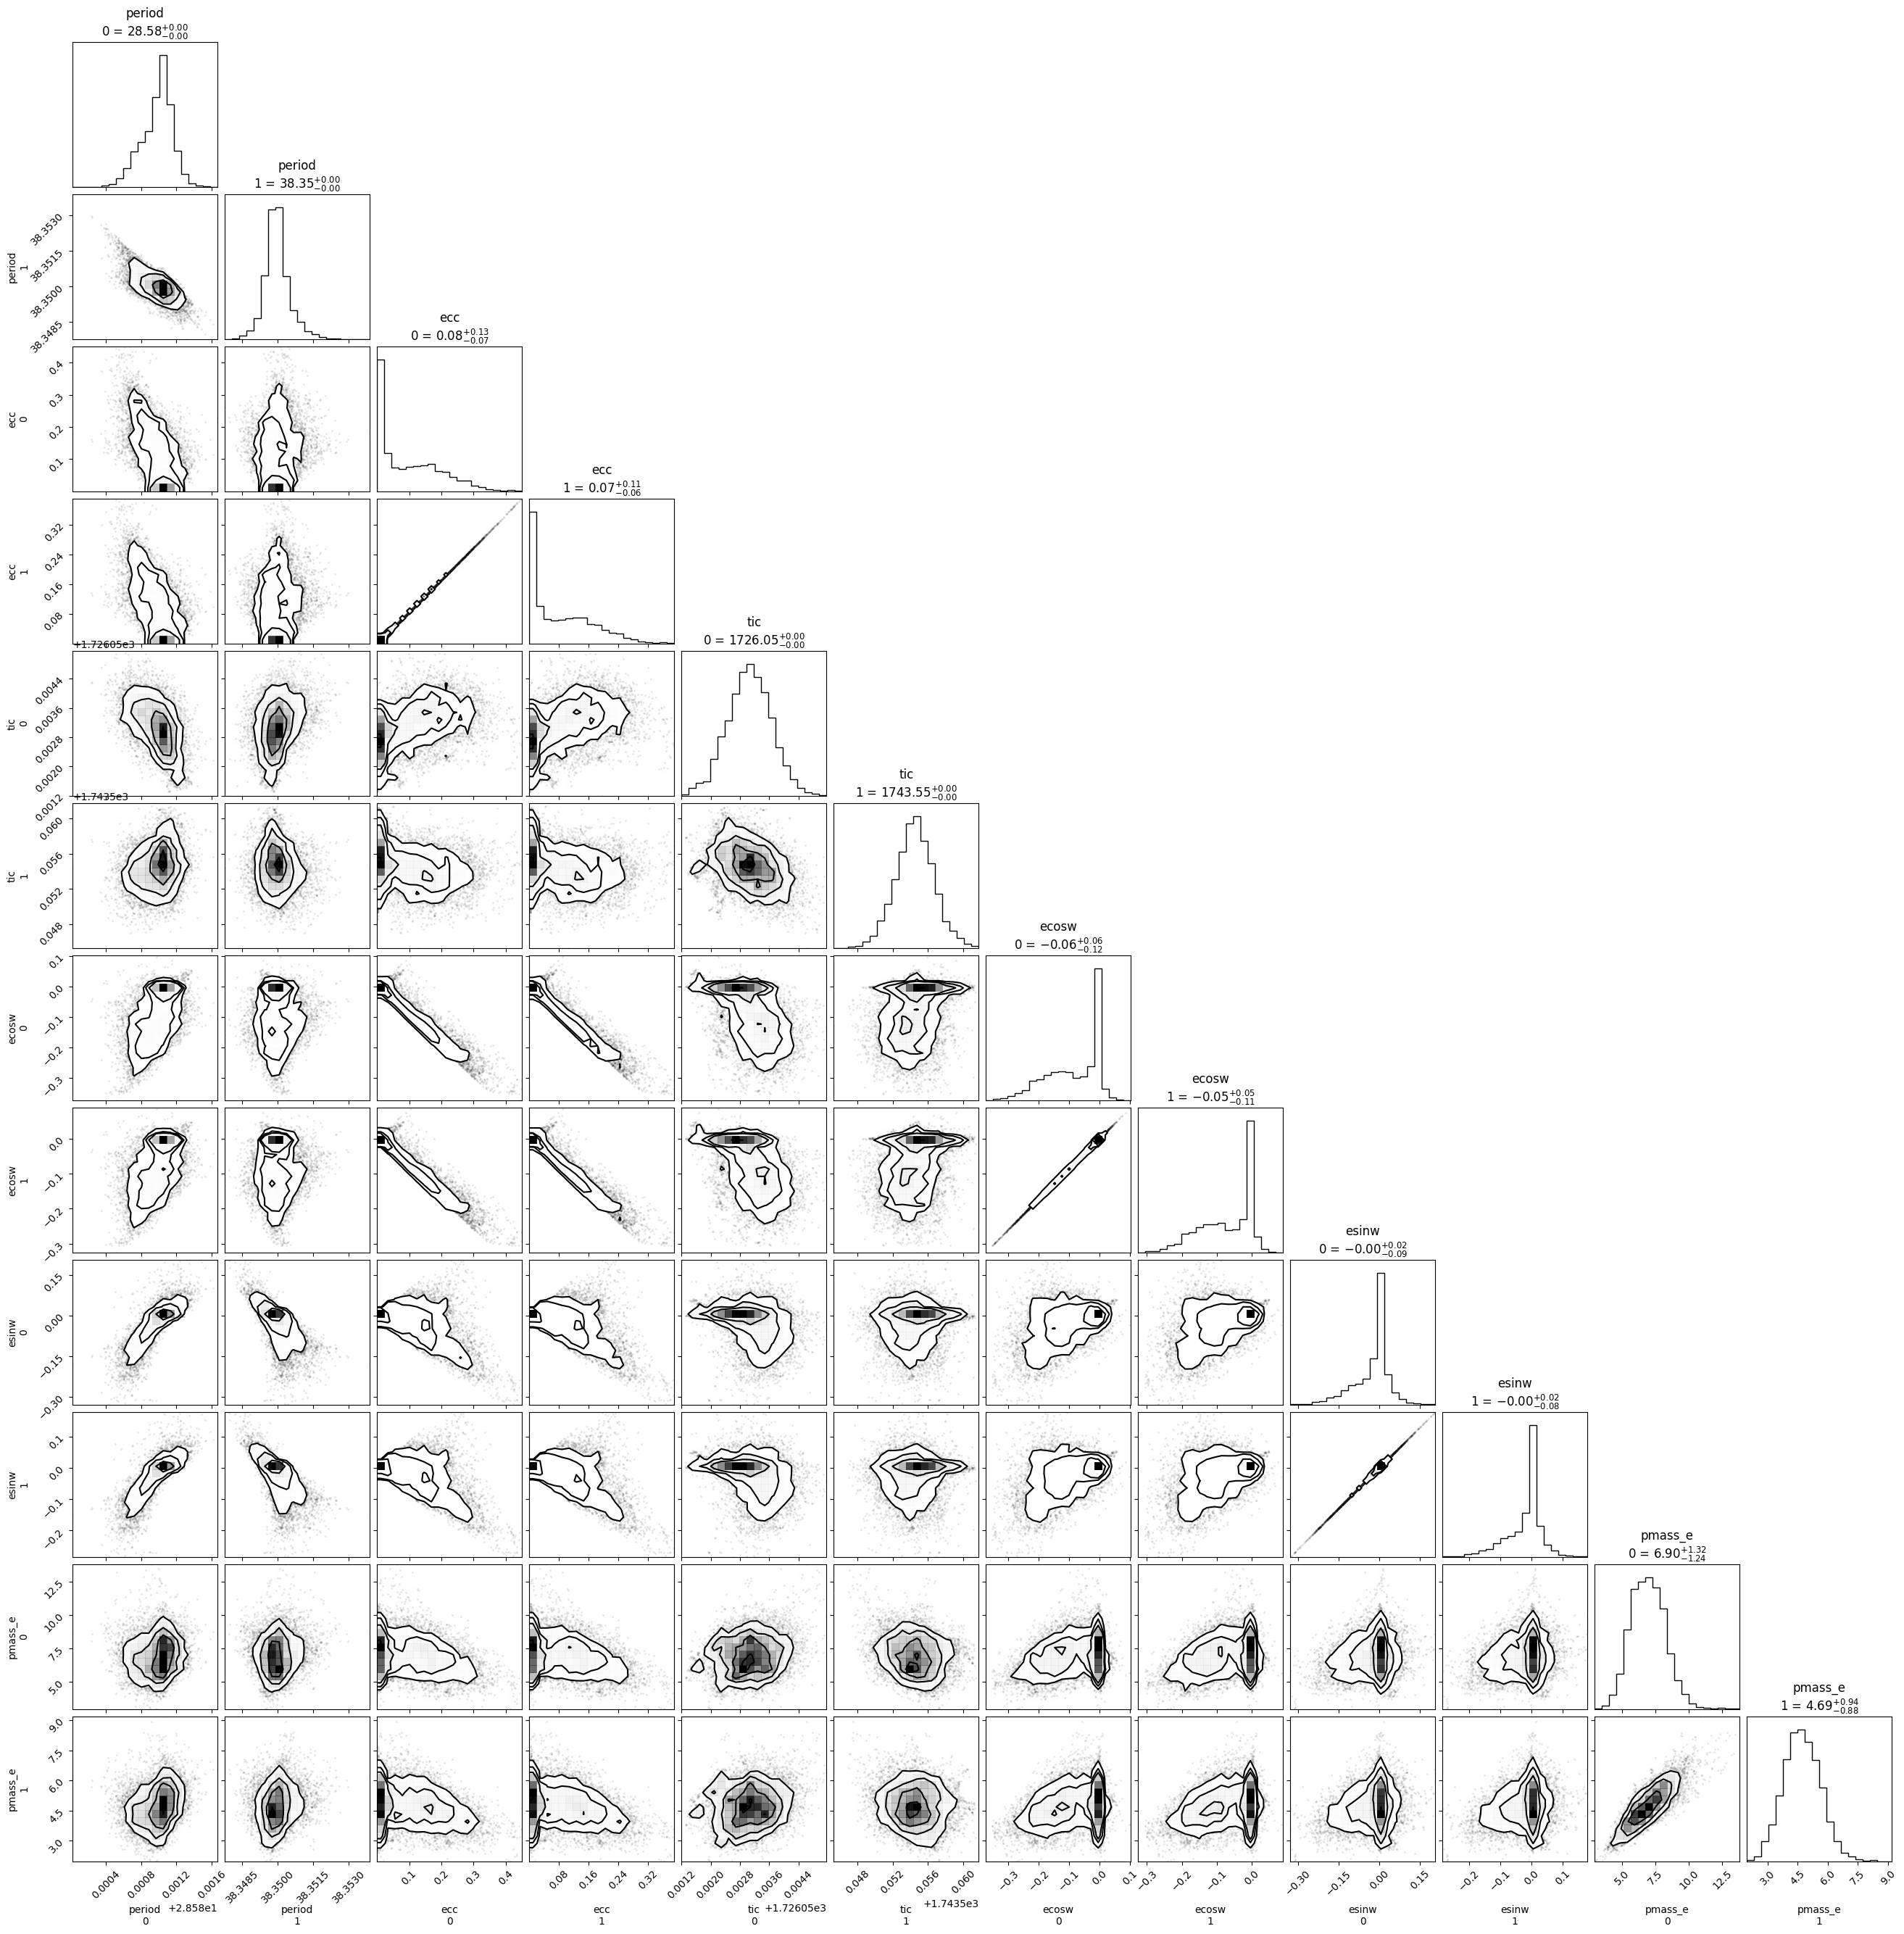

In [13]:
idata.posterior['pmass_e'] = idata.posterior['pmass'] / 3.003e-6
names = ["period", "ecc", "tic", "ecosw", "esinw", "pmass_e"]
fig = corner.corner(idata, var_names=names, show_titles=True)

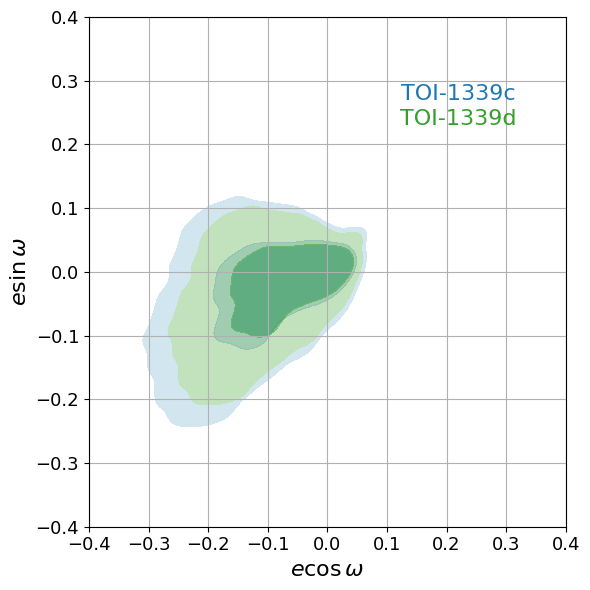

In [14]:
### 2D posterior for ecosw and esinw 
ecosw_c = samples["ecosw"][:, 0]
esinw_c = samples["esinw"][:, 0]

ecosw_d = samples["ecosw"][:, 1]
esinw_d = samples["esinw"][:, 1]

import matplotlib.pyplot as plt
# import seaborn as sns
from scipy.stats import gaussian_kde


def compute_kde_contour_levels(x, y, gridsize=100):
    data = np.vstack([x, y])
    kde = gaussian_kde(data)
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    X, Y = np.mgrid[x_min:x_max:gridsize*1j, y_min:y_max:gridsize*1j]
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kde(positions).T, X.shape)
    return X, Y, Z, kde

def get_sigma_contour_levels(Z):
    Z_flat = Z.flatten()
    Z_sorted = np.sort(Z_flat)[::-1]
    cumsum = np.cumsum(Z_sorted)
    cumsum /= cumsum[-1]
    levels = []
    for sigma in [0.683, 0.954]:
        idx = np.searchsorted(cumsum, sigma)
        levels.append(Z_sorted[idx])
    return sorted(levels)  # ensures ascending order

# Compute KDEs
Xc, Yc, Zc, kde_c = compute_kde_contour_levels(ecosw_c, esinw_c)
Xd, Yd, Zd, kde_d = compute_kde_contour_levels(ecosw_d, esinw_d)

# Get contour levels
levels_c = get_sigma_contour_levels(Zc)
levels_d = get_sigma_contour_levels(Zd)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Filled contours for planet c (blue shades)
ax.contourf(Xc, Yc, Zc, levels=levels_c + [Zc.max()], colors=['#a6cee3', '#1f78b4'], alpha=0.5)

# Filled contours for planet d (green shades)
ax.contourf(Xd, Yd, Zd, levels=levels_d + [Zd.max()], colors=['#b2df8a', '#33a02c'], alpha=0.5)

# Text annotation
ax.text(0.22, 0.27, 'TOI-1339c', color='#1f78b4', fontsize=16, ha='center')
ax.text(0.22, 0.23, 'TOI-1339d', color='#33a02c', fontsize=16, ha='center')


# Labels and legend
ax.set_xlabel(r"$e \cos\omega$", fontsize=16)
ax.set_ylabel(r"$e \sin\omega$", fontsize=16)
# ax.set_title("2D Joint Posterior of $e  cos(\omega)$ and $e sin(\omega)$")
blue_patch = plt.Line2D([], [], color='#a6cee3', label='Planet c')
red_patch = plt.Line2D([], [], color='#b2df8a', label='Planet d')
# ax.legend(handles=[blue_patch, red_patch])


# plt.grid(True)
plt.tick_params(axis='both', labelsize=13) 
plt.xlim(-0.40,0.40)
plt.ylim(-0.40,0.40)
plt.grid(True)
plt.tight_layout()
plt.show()

# Extracting values from posteriors 

In [15]:
### posterior samples 
ecosw_c = samples["ecosw"][:, 0]
esinw_c = samples["esinw"][:, 0]
Per_c = samples["period"][:,0] # [days]
Tc_c = samples["tic"][:,0] # [days]
pmass_c = samples["pmass"][:, 0] # [solar mass]

ecosw_d = samples["ecosw"][:, 1]
esinw_d = samples["esinw"][:, 1]
Per_d = samples["period"][:,1] # [days]
Tc_d = samples["tic"][:,1] # [days]
pmass_d = samples["pmass"][:, 1] # [solar mass]

### convert planet mass from solar to earth masses 
import astropy.constants as u
convert = (u.M_sun / u.M_earth).value
pmass_earth_c = pmass_c * convert
pmass_earth_d = pmass_d * convert


# Compute eccentricity and omega (in radians and degrees) for each sample
ecc_c = np.sqrt(ecosw_c**2 + esinw_c**2)
omega_rad_c = np.arctan2(esinw_c, ecosw_c)
omega_deg_c = np.rad2deg(omega_rad_c)

# Compute eccentricity and omega (in radians and degrees) for each sample
ecc_d = np.sqrt(ecosw_d**2 + esinw_d**2)
omega_rad_d = np.arctan2(esinw_d, ecosw_d)
omega_deg_d = np.rad2deg(omega_rad_d)


### keep Omega constant
value_Omega_c = 0  # [deg]
Omega_c = [np.radians(value_Omega_c)] * len(omega_rad_c)  # [rad]
value_Omega_d = 0 # [deg]
Omega_d = [np.radians(value_Omega_d)] * len(omega_rad_d)  # [rad]

pomega_rad_c = omega_rad_c + Omega_c
pomega_rad_d = omega_rad_d + Omega_d


Delta_omega_rad = omega_rad_d - omega_rad_c
Delta_omega_deg = omega_deg_d - omega_deg_c

In [16]:
def get_median_and_1sigma(samples):
    median = np.median(samples)
    lower = np.percentile(samples, 16)
    upper = np.percentile(samples, 84)
    return median, median - lower, upper - median


In [17]:
# Planet c
Per_c_med, Per_c_lo, Per_c_hi = get_median_and_1sigma(Per_c)
Tc_c_med, Tc_c_lo, Tc_c_hi = get_median_and_1sigma(Tc_c)
esinw_c_med, esinw_c_lo, esinw_c_hi = get_median_and_1sigma(esinw_c)
ecosw_c_med, ecosw_c_lo, ecosw_c_hi = get_median_and_1sigma(ecosw_c)
ecc_c_median, ecc_c_lo, ecc_c_hi = get_median_and_1sigma(ecc_c)
omega_deg_c_median, omega_deg_c_lo, omega_deg_c_hi = get_median_and_1sigma(omega_deg_c)
pmass_earth_c_median, pmass_earth_c_lo, pmass_earth_c_hi = get_median_and_1sigma(pmass_earth_c)

# Planet 
Per_d_med, Per_d_lo, Per_d_hi = get_median_and_1sigma(Per_d)
Tc_d_med, Tc_d_lo, Tc_d_hi = get_median_and_1sigma(Tc_d)
esinw_d_med, esinw_d_lo, esinw_d_hi = get_median_and_1sigma(esinw_d)
ecosw_d_med, ecosw_d_lo, ecosw_d_hi = get_median_and_1sigma(ecosw_d)
ecc_d_median, ecc_d_lo, ecc_d_hi = get_median_and_1sigma(ecc_d)
omega_deg_d_median, omega_deg_d_lo, omega_deg_d_hi = get_median_and_1sigma(omega_deg_d)
pmass_earth_d_median, pmass_earth_d_lo, pmass_earth_d_hi = get_median_and_1sigma(pmass_earth_d)

# Difference in omega
Delta_omega_deg_median, Delta_omega_deg_lo, Delta_omega_deg_hi = get_median_and_1sigma(Delta_omega_deg)


In [18]:
print(f"Period_c = {Per_c_med:.5f} (+{Per_c_hi:.5f}/-{Per_c_lo:.5f}) days")
print(f"Tc_c = {Tc_c_med:.5f} (+{Tc_c_hi:.5f}/-{Tc_c_lo:.5f}) days")
print(f"esinω_c = {esinw_c_med:.4f} (+{esinw_c_hi:.4f}/-{esinw_c_lo:.4f})")
print(f"ecosω_c = {ecosw_c_med:.4f} (+{ecosw_c_hi:.4f}/-{ecosw_c_lo:.4f})")
print(f"Ecc_c = {ecc_c_median:.3f} (+{ecc_c_hi:.3f}/-{ecc_c_lo:.3f})")
print(f"ω_c (deg) = {omega_deg_c_median:.1f} (+{omega_deg_c_hi:.1f}/-{omega_deg_c_lo:.1f})")
print(f"Mass_c (Earth) = {pmass_earth_c_median:.2f} (+{pmass_earth_c_hi:.2f}/-{pmass_earth_c_lo:.2f})")
print('\n')

print(f"Period_d = {Per_d_med:.5f} (+{Per_d_hi:.5f}/-{Per_d_lo:.5f}) days")
print(f"Tc_d = {Tc_d_med:.5f} (+{Tc_d_hi:.5f}/-{Tc_d_lo:.5f}) days")
print(f"esinω_d = {esinw_d_med:.4f} (+{esinw_d_hi:.4f}/-{esinw_d_lo:.4f})")
print(f"ecosω_d = {ecosw_d_med:.4f} (+{ecosw_d_hi:.4f}/-{ecosw_d_lo:.4f})")
print(f"Ecc_d = {ecc_d_median:.3f} (+{ecc_d_hi:.3f}/-{ecc_d_lo:.3f})")
print(f"ω_d (deg) = {omega_deg_d_median:.1f} (+{omega_deg_d_hi:.1f}/-{omega_deg_c_lo:.1f})")
print(f"Mass_d (Earth) = {pmass_earth_d_median:.2f} (+{pmass_earth_d_hi:.2f}/-{pmass_earth_d_lo:.2f})")
print('\n')

print(f"Δω (deg) = {Delta_omega_deg_median:.1f} (+{Delta_omega_deg_hi:.1f}/-{Delta_omega_deg_lo:.1f})")


Period_c = 28.58103 (+0.00013/-0.00022) days
Tc_c = 1726.05301 (+0.00059/-0.00069) days
esinω_c = -0.0022 (+0.0211/-0.0811)
ecosω_c = -0.0359 (+0.0357/-0.1432)
Ecc_c = 0.053 (+0.155/-0.050)
ω_c (deg) = -119.6 (+270.7/-40.8)
Mass_c (Earth) = 7.07 (+1.15/-1.21)


Period_d = 38.34993 (+0.00043/-0.00038) days
Tc_d = 1743.55478 (+0.00223/-0.00208) days
esinω_d = -0.0008 (+0.0181/-0.0698)
ecosω_d = -0.0289 (+0.0306/-0.1240)
Ecc_d = 0.045 (+0.133/-0.042)
ω_d (deg) = -48.4 (+194.6/-40.8)
Mass_d (Earth) = 4.84 (+0.85/-0.92)


Δω (deg) = -0.2 (+13.6/-3.7)


In [19]:
def resonant_bandwidth(j, m1, m2, m_star):
    term1 = (j-1) / j**(2./3.)
    term2 = ((m1+m2) / m_star)**(2./3.)
    res_bw = 5*term1*term2
    return res_bw *100 # percents

m_star = 0.81 # [solar mass]

res_bw = resonant_bandwidth(4, pmass_d, pmass_c, m_star)

res_bw_med, res_bw_lo, res_bw_hi = get_median_and_1sigma(res_bw)
print(f"Resonant bw = {res_bw_med:.4f} (+{res_bw_hi:.4f}/-{res_bw_lo:.4f})")

Resonant bw = 0.7438 (+0.0772/-0.0876)


In [20]:
def delta_res(P1, P2, j):
    term1 = P2 / P1
    term2 = ((j-1)/j)
    delta = term1*term2 - 1
    return delta * 100 # percents

delta = delta_res(Per_c, Per_d, 4)

delta_med, delta_hi, delta_lo = get_median_and_1sigma(delta)
print(f"Delta res = {delta_med:.4f} (+{delta_hi:.4f}/-{delta_lo:.4f})")

Delta res = 0.6348 (+0.0013/-0.0017)


In [21]:
def delta_chi_2017(j, m1, m2, m_star):
    term1 = j**(1./3.)
    term2 = ((m1+m2) / m_star)**(2./3.)
    res_bw = 5*term1*term2
    return res_bw *100 # percents

delta_chi = delta_chi_2017(4, pmass_d, pmass_c, m_star)
delta_chi_med, delta_chi_lo, delta_chi_hi = get_median_and_1sigma(delta_chi)
print(f"Delta chi = {delta_chi_med:.4f} (+{delta_chi_hi:.4f}/-{delta_chi_lo:.4f})")

from astropy.constants import M_earth, M_sun
conversion = (M_earth.value / M_sun.value)
print(np.median(pmass_c) / conversion)
print(np.median(pmass_d) / conversion)
print(np.median((pmass_d+pmass_c)/m_star))

Delta chi = 0.9917 (+0.1029/-0.1168)
7.070457490201719
4.843385978282459
4.4164235450620134e-05


# Save for paper

In [22]:
Per_c_med = round(Per_c_med, 4)
Per_c_hi = round(Per_c_hi, 4)
Per_c_lo = round(Per_c_lo, 4)
Tc_c_med = round(Tc_c_med, 4)
Tc_c_hi = round(Tc_c_hi, 4)
Tc_c_lo = round(Tc_c_lo, 4)
esinw_c_med = round(esinw_c_med, 2)
esinw_c_hi = round(esinw_c_hi, 2)
esinw_c_lo = round(esinw_c_lo, 2)
ecosw_c_med = round(ecosw_c_med, 2)
ecosw_c_hi = round(ecosw_c_hi, 2)
ecosw_c_lo = round(ecosw_c_lo, 2)
ecc_c_median = round(ecc_c_median, 2)
ecc_c_hi = round(ecc_c_hi,2)
ecc_c_lo = round(ecc_c_lo,2)
omega_deg_c_median = round(omega_deg_c_median, 2)
omega_deg_c_hi = round(omega_deg_c_hi, 2)
omega_deg_c_lo = round(omega_deg_c_lo, 2)
pmass_earth_c_median = round(pmass_earth_c_median, 1)
pmass_earth_c_hi = round(pmass_earth_c_hi, 1)
pmass_earth_c_lo = round(pmass_earth_c_lo, 1)

Per_d_med = round(Per_d_med, 4)
Per_d_hi = round(Per_d_hi, 4)
Per_d_lo = round(Per_d_lo, 4)
Tc_d_med = round(Tc_d_med, 4)
Tc_d_hi = round(Tc_d_hi, 4)
Tc_d_lo = round(Tc_d_lo, 4)
esinw_d_med = round(esinw_d_med, 2)
esinw_d_hi = round(esinw_d_hi, 2)
esinw_d_lo = round(esinw_d_lo, 2)
ecosw_d_med = round(ecosw_d_med, 2)
ecosw_d_hi = round(ecosw_d_hi, 2)
ecosw_d_lo = round(ecosw_d_lo, 2)
ecc_d_median = round(ecc_d_median, 2)
ecc_d_hi = round(ecc_d_hi,2)
ecc_d_lo = round(ecc_d_lo,2)
omega_deg_d_median = round(omega_deg_d_median, 2)
omega_deg_d_hi = round(omega_deg_d_hi, 2)
omega_deg_d_lo = round(omega_deg_d_lo, 2)
pmass_earth_d_median = round(pmass_earth_d_median, 1)
pmass_earth_d_hi = round(pmass_earth_d_hi, 1)
pmass_earth_d_lo = round(pmass_earth_d_lo, 1)

Delta_omega_deg_median = round(Delta_omega_deg_median, 1)
Delta_omega_deg_hi = round(Delta_omega_deg_hi, 1)
Delta_omega_deg_lo = round(Delta_omega_deg_lo, 1)

In [23]:
### sourced from literature 
# stellar - lubin 2024
mstar_val, mstar_err = 0.81, 0.04
rstar_val, rstar_err = 0.94, 0.02
teff_val, teff_err = 5348, 100 # [K]
logg_val, logg_err = 4.3, 0.1 # [dex]
metallicity_val, metallicity_err = -0.15, 0.06 # [dex]


# q1_val, q1_err = 0.4, 0.1
# q2_val, q2_err = 0.3, 0.2
# from ldtk
u1_tess_val, u1_tess_err = 0.4422, 0.0018
u2_tess_val, u2_tess_err = 0.1470, 0.0029
### 1=c 2=d, orell-mmiquel
inc1_val, inc1_err_hi, inc1_err_lo = 89.10, 0.06, 0.08
inc2_val, inc2_err_hi, inc2_err_lo = 89.49, 0.05, 0.08

ror1_val, ror1_err_hi, ror1_err_lo = 0.03118, 0.00027, 0.00034
ror2_val, ror2_err_hi, ror2_err_lo = 0.02916, 0.00034, 0.00021

b1_val, b1_err_hi, b1_err_lo = 0.630, 0.050, 0.030
b2_val, b2_err_hi, b2_err_lo = 0.440, 0.050, 0.030

T14_1_val, T14_1_err_hi, T14_1_err_lo = 4.162, 0.240, 0.096 # hours, 
T14_2_val, T14_2_err_hi, T14_2_err_lo = 5.36, 0.19, 0.11

from astropy.constants import R_earth, R_sun, M_earth, M_sun
# rade1_val = ror1_value * rstar_val * (R_earth/R_sun)
# from orell miquel
rade1_val, rade1_err = 3.195, 0.075
rade2_val, rade2_err = 2.995, 0.070



### planet b params from literature as of now 
masse_b, masse_b_err = 10.00, 0.70
rade_b, rade_b_err = 3.410, 0.075
Per_b, Per_b_err = 8.8803256, 0.0000047

## calculate density

In [25]:
### bulk density 
def bulk_density(mass, radius, sigma_mass, sigma_radius):
    volume = (4./3.) * np.pi * radius**3   # assuming spherical 
    rho = mass / volume

    frac_err_mass = sigma_mass / mass
    frac_err_radius = sigma_radius / radius
    # error propagation: (σρ/ρ)^2 = (σM/M)^2 + 9 (σR/R)^2
    frac_err_rho = np.sqrt(frac_err_mass**2 + 9 * frac_err_radius**2)
    sigma_rho = rho * frac_err_rho
    # convert to g/cm^3
    conversion = (1000 / (100**3))
    return rho*conversion, sigma_rho*conversion

mass_b = masse_b * M_earth.value 
sigma_m_b = masse_b_err * M_earth.value 
rad_b = rade_b * R_earth.value
sigma_rad_b = rade_b_err * R_earth.value

# print(bulk_density(4.09 * M_earth.value ,2.62 * R_earth.value,0.4 * M_earth.value ,0.11 * R_earth.value))

rho_b, rho_err_b = bulk_density(mass_b, rad_b, sigma_m_b, sigma_rad_b)
print(rho_b, rho_err_b)

1.3858182870227351 0.13331022861431654


In [26]:
def bulk_density_asym_log(mass_med, mass_lo, mass_hi,
                          radius_med, radius_err):
    """
    Compute bulk density and asymmetric 1-sigma errors using log-space propagation.
    mass_med, mass_lo, mass_hi: median and +/-1sigma offsets for mass (mass_lo/mass_hi > 0)
        interpreted such that mass_low_val = mass_med - mass_lo, mass_high_val = mass_med + mass_hi.
    radius_med, radius_err: median and symmetric 1sigma for radius (radius_err > 0)
    Units: by default inputs are in Earth units; set mass_in_earth or radius_in_earth False if already SI.

    Returns:
      rho_med, rho_err_lo, rho_err_hi, rho_med_gcm3, rho_err_lo_gcm3, rho_err_hi_gcm3
      where rho_err_lo = rho_med - rho_lower (positive), rho_err_hi = rho_upper - rho_med (positive).
    """

    M_med = mass_med * M_earth.value
    M_low_val = (mass_med - mass_lo) * M_earth.value
    M_high_val = (mass_med + mass_hi) * M_earth.value
    

    R_med = radius_med * R_earth.value
    R_low_val = (radius_med - radius_err) * R_earth.value
    R_high_val = (radius_med + radius_err) * R_earth.value
    
    # Basic checks
    if M_low_val <= 0 or R_low_val <= 0:
        raise ValueError("Lower bound on mass or radius is non-physical (<= 0). Use a posterior/sampling method.")

    # median density
    rho_med = M_med / ((4.0/3.0) * np.pi * R_med**3)

    # Convert asymmetric mass errors to log-space sigmas:
    lnM_med = np.log(M_med)
    lnM_low  = np.log(M_low_val)
    lnM_high = np.log(M_high_val)
    sigma_lnM_lo = lnM_med - lnM_low   # positive
    sigma_lnM_hi = lnM_high - lnM_med  # positive

    # Convert symmetric radius error to log-space sigma (use exact ln form)
    lnR_med = np.log(R_med)
    lnR_high = np.log(R_high_val)
    # radius error is symmetric so sigma_lnR (use + side)
    sigma_lnR = lnR_high - lnR_med     # positive

    # Propagate in log-space: ln rho = ln M - 3 ln R
    sigma_lnrho_lo = np.sqrt(sigma_lnM_lo**2 + (3.0 * sigma_lnR)**2)
    sigma_lnrho_hi = np.sqrt(sigma_lnM_hi**2 + (3.0 * sigma_lnR)**2)

    # Convert back to linear space: multiplicative factors
    rho_low  = rho_med * np.exp(-sigma_lnrho_lo)
    rho_high = rho_med * np.exp( sigma_lnrho_hi)

    rho_err_lo = rho_med - rho_low   # positive
    rho_err_hi = rho_high - rho_med  # positive

    # also return in g/cm^3
    rho_med_g = rho_med * 1e-3
    rho_err_lo_g = rho_err_lo * 1e-3
    rho_err_hi_g = rho_err_hi * 1e-3

    return (rho_med_g, rho_err_lo_g, rho_err_hi_g)



rho_med_c, rho_err_lo_c, rho_err_hi_c = bulk_density_asym_log(pmass_earth_c_median, pmass_earth_c_lo, pmass_earth_c_hi, rade1_val, rade1_err)
print(f"rho = {rho_med_c:.3f} -{rho_err_lo_c:.3f} +{rho_err_hi_c:.3f} g/cm^3")

rho_med_d, rho_err_lo_d, rho_err_hi_d = bulk_density_asym_log(pmass_earth_d_median, pmass_earth_d_lo, pmass_earth_d_hi, rade2_val, rade2_err)
print(f"rho = {rho_med_d:.3f} -{rho_err_lo_d:.3f} +{rho_err_hi_d:.3f} g/cm^3")

rho = 1.196 -0.215 +0.208 g/cm^3
rho = 0.982 -0.193 +0.200 g/cm^3


## Calculate TSM

In [27]:
### tramsission spectroscopy metric TSM
def TSM_(scale_factor, radius_p, mass_p, radius_star, T_eq, m_j):
    term_num = (radius_p**3) * T_eq
    term_den = mass_p * (radius_star**2)
    term1 = term_num / term_den
    term2 = 10**(-m_j/5)
    TSM = scale_factor * term1 * term2
    return TSM

def T_equilibrium(r_star, T_star, a_planet):
    term1 = np.sqrt(r_star/a_planet)
    term2 = (1./4.)**(1./4.)
    T_eq = T_star * term1 * term2
    return T_eq

scale_factor = 1.28 # kempton 2018

T_star = 5348
r_star = 0.94
m_j = 7.597
from astropy import units as u
from astropy import constants as c
G_const_si = c.G
G_const = c.G.to(u.R_sun**3 / u.M_sun / u.day**2).value
print(G_const)

a_b = ((G_const*m_star*Per_b**2)/(4*np.pi**2))**(1.0/3.)
a_c = ((G_const*m_star*Per_c_med**2)/(4*np.pi**2))**(1.0/3.)
a_d = ((G_const*m_star*Per_d_med**2)/(4*np.pi**2))**(1.0/3.)

T_eq_b = T_equilibrium(r_star, T_star, a_b)
T_eq_c = T_equilibrium(r_star, T_star, a_c)
T_eq_d = T_equilibrium(r_star, T_star, a_d)

TSM_b = int(TSM_(scale_factor, rade_b, masse_b, r_star, T_eq_b, m_j))
TSM_c = int(TSM_(scale_factor, rade1_val, pmass_earth_c_median, r_star, T_eq_c, m_j))
TSM_d = int(TSM_(scale_factor, rade2_val, pmass_earth_d_median, r_star, T_eq_d, m_j))

print(TSM_b)
print(TSM_c)
print(TSM_d)

2942.2062175044193
155
121
134


## read in table 3 fenv model

In [50]:
df_100myr = pd.read_csv(
    'model_table_100myr.txt',
    sep=r'\s+',         # regex for 1+ spaces
    skiprows=3,         # adjust to skip header/title lines
    engine='python'     # sometimes needed for regex separator
)

df_1gyr = pd.read_csv(
    'model_table_1gyr.txt',
    sep=r'\s+',         # regex for 1+ spaces
    skiprows=3,         # adjust to skip header/title lines
    engine='python'     # sometimes needed for regex separator
)

df_10gyr = pd.read_csv(
    'model_table_10gyr.txt',
    sep=r'\s+',         # regex for 1+ spaces
    skiprows=3,         # adjust to skip header/title lines
    engine='python'     # sometimes needed for regex separator
)
print(df_10gyr)

ages = np.array([0.1, 1.0, 10.0]) # in Gyr

    Flux(F_oplus)  Mass(M_oplus)  0.01%  0.02%  0.05%  0.1%  0.2%  0.5%    1%  \
0           0.100          1.000  1.080  1.100  1.130 1.170 1.220 1.370 1.530   
1           0.100          1.500  1.190  1.200  1.230 1.270 1.310 1.450 1.600   
2           0.100          2.400  1.320  1.340  1.370 1.400 1.450 1.580 1.710   
3           0.100          3.600  1.450  1.470  1.490 1.530 1.580 1.700 1.820   
4           0.100          5.500  1.600  1.620  1.640 1.670 1.750 1.840 1.960   
5           0.100          8.500  1.770  1.780  1.800 1.840 1.910 2.000 2.130   
6           0.100         13.000  1.940  1.950  1.970 2.000 2.090 2.170 2.300   
7           0.100         20.000  2.120  2.140  2.160 2.190 2.250 2.360 2.490   
8          10.000          1.000  1.230  1.250  1.280 1.310 1.440 1.680 1.870   
9          10.000          1.500  1.310  1.330  1.360 1.400 1.490 1.720 1.900   
10         10.000          2.400  1.430  1.440  1.470 1.510 1.600 1.780 1.960   
11         10.000          3

In [51]:
fenv_cols = df_10gyr.columns[2:]
print(fenv_cols)

# envelope fractions as decimals 
f_envs = np.array([float(c.replace('%', ''))/100 for c in fenv_cols])

Index(['0.01%', '0.02%', '0.05%', '0.1%', '0.2%', '0.5%', '1%', '2%', '5%',
       '10%', '20%'],
      dtype='object')


In [52]:
### mass and flux values same for three models 
flux_array = df_10gyr['Flux(F_oplus)'].values
mass_array = df_10gyr['Mass(M_oplus)'].values
fluxes = np.sort(np.unique(flux_array))
masses = np.sort(np.unique(mass_array))


In [70]:
radii_table = np.zeros((len(ages), len(fluxes),len(masses), len(f_envs)))

for k, df in enumerate([df_100myr, df_1gyr, df_10gyr]):
    for i, F in enumerate(fluxes):
        for j, M in enumerate(masses):
            idx = np.where((flux_array == F) & (mass_array == M))[0][0]
            radii_table[k, i, j, :] = df.loc[idx, fenv_cols].values


In [71]:
print("radii_table shape:", radii_table.shape)
print("fluxes:", fluxes)
print("masses:", masses)
print("f_envs:", f_envs)
print(radii_table)

radii_table shape: (3, 3, 8, 11)
fluxes: [1.e-01 1.e+01 1.e+03]
masses: [ 1.   1.5  2.4  3.6  5.5  8.5 13.  20. ]
f_envs: [1.e-04 2.e-04 5.e-04 1.e-03 2.e-03 5.e-03 1.e-02 2.e-02 5.e-02 1.e-01
 2.e-01]
[[[[ 1.22  1.16  1.18  1.21  1.32  1.65  2.17  2.75  4.32  6.81 11.7 ]
   [ 1.3   1.24  1.26  1.3   1.4   1.71  2.15  2.65  3.97  6.18 10.6 ]
   [ 1.41  1.36  1.4   1.42  1.53  1.79  2.17  2.58  3.66  5.36  9.05]
   [ 1.53  1.49  1.51  1.54  1.64  1.89  2.21  2.56  3.49  4.93  7.86]
   [ 1.66  1.63  1.66  1.69  1.79  2.01  2.28  2.6   3.37  4.58  6.96]
   [ 1.81  1.79  1.82  1.85  1.95  2.14  2.39  2.67  3.36  4.35  6.32]
   [ 1.97  1.97  1.98  2.02  2.11  2.3   2.52  2.78  3.41  4.29  5.94]
   [ 2.15  2.15  2.17  2.2   2.29  2.47  2.67  2.93  3.52  4.32  5.75]]

  [[ 1.32  1.24  1.27  1.31  1.44  1.82  2.4   3.06  4.72  7.13 11.1 ]
   [ 1.36  1.32  1.35  1.38  1.5   1.84  2.32  2.88  4.31  6.47 10.4 ]
   [ 1.46  1.43  1.48  1.5   1.59  1.88  2.26  2.71  3.88  5.67  9.14]
   [ 1.57  1.55

In [72]:
def sample_asymmetric_normal(median, lo, hi, nsamp=10000):
    """
    Sample from a split-normal (two-piece normal) distribution defined
    by median, lower bound (lo), and upper bound (hi).
    Here lo and hi are the 1-sigma distances: median - lo_val, hi_val - median.
    If lo==hi (or one is None), falls back to symmetric normal.
    
    Parameters
    ----------
    median : float
        central value
    lo : float
        lower 1-sigma bound (value < median) OR absolute sigma_left (positive)
        If given as the upper bound value, the function expects the caller to pass
        the lower sigma = median - lo_value. (See usage below.)
    hi : float
        upper 1-sigma bound (value > median) OR absolute sigma_right (positive)
    nsamp : int
        number of samples
    Returns
    -------
    samples : ndarray (nsamp,)
    """
    # Interpret arguments: if lo < median and hi > median assume they are values, convert
    # to sigmas: sigma_left = median - lo, sigma_right = hi - median
    sigma_left = None
    sigma_right = None
    if (lo is not None) and (hi is not None) and (lo < median < hi):
        sigma_left = median - lo
        sigma_right = hi - median
    else:
        # assume lo and hi are sigmas already (positive)
        if lo is None and hi is None:
            raise ValueError("Provide either (lo_value, hi_value) or (sigma_left, sigma_right).")
        sigma_left = float(lo) if lo is not None else float(hi)
        sigma_right = float(hi) if hi is not None else float(lo)

    # if sigmas are (nearly) equal, do symmetric normal
    if np.isclose(sigma_left, sigma_right):
        return np.random.normal(loc=median, scale=sigma_left, size=nsamp)

    # split-normal: draw standard normal z; scale negative z by sigma_left, positive by sigma_right
    z = np.random.normal(size=nsamp)
    z_scaled = np.where(z < 0, z * sigma_left, z * sigma_right)
    return median + z_scaled

def sample_symmetric_normal(val, sigma, nsamp=10000):
    return np.random.normal(loc=val, scale=sigma, size=nsamp)

# -----------------------
# Kepler -> semi-major axis (AU)
# -----------------------
def semi_major_axis_from_period(P_days, Mstar_Msun):
    P = (P_days * u.day).to(u.s)
    Mstar = (Mstar_Msun * const.M_sun).to(u.kg)
    a = ( (const.G * Mstar * P**2) / (4 * np.pi**2) )**(1/3)
    return a.to(u.AU).value

def incident_flux_Fearth(Lstar_over_Lsun, a_AU):
    return (Lstar_over_Lsun) * (a_AU**-2)

# -----------------------
# your Lopez inversion function (expects Earth units)
# (use the version you already validated)
# -----------------------
def f_env_from_lopez(Rp, Mp, Fp, age_Gyr):
    coef = 2.06
    a_mp = -0.21
    a_fenv = 0.59
    a_fp = 0.044
    a_age = -0.18

    R_core = Mp**0.25
    R_env = Rp - R_core
    if R_env <= 0:
        return 0.0

    factor = (R_env / coef) * (Mp ** (+0.21)) * (Fp ** (-0.044)) * ((age_Gyr/5.0) ** (+0.18))
    if factor <= 0 or not np.isfinite(factor):
        return 0.0
    f_env = 0.05 * (factor ** (1.0 / a_fenv))
    return float(np.clip(f_env, 0.0, 1.0))

# -----------------------
# Monte Carlo wrapper handling asymmetric/symmetric errors
# -----------------------
def fenv_mc_with_errors(
    Rp, Rp_err_sym,  # radius and symmetric 1-sigma error (R_earth)
    Mp_median, Mp_lo_or_sigma, Mp_hi_or_sigma,  # for asymmetric: pass lo_value, hi_value; for symmetric pass sigma twice
    P_median, P_lo_or_sigma, P_hi_or_sigma,     # period (days) same pattern
    Mstar_Msun, Lstar_over_Lsun, age_Gyr,
    nsamp=20000
):
    """
    Return median, 16th, 84th percentiles of f_env and intermediate diagnostics.
    Mp_{lo,hi} and P_{lo,hi} may be provided either as absolute bounds (values) or as sigmas.
    For convenience, if you have symmetric error just pass sigma for lo and hi.
    """
    # Radius: symmetric normal
    Rp_samps = sample_symmetric_normal(Rp, Rp_err_sym, nsamp=nsamp)

    # Mass: determine if the user passed bounds or sigmas
    # If they passed lo < median < hi treat lo/hi as bound-values (common usage)
    if (Mp_lo_or_sigma is not None) and (Mp_hi_or_sigma is not None) and (Mp_lo_or_sigma < Mp_median < Mp_hi_or_sigma):
        Mp_samps = sample_asymmetric_normal(Mp_median, Mp_lo_or_sigma, Mp_hi_or_sigma, nsamp=nsamp)
    else:
        Mp_samps = sample_asymmetric_normal(Mp_median, Mp_lo_or_sigma, Mp_hi_or_sigma, nsamp=nsamp)

    # Period:
    if (P_lo_or_sigma is not None) and (P_hi_or_sigma is not None) and (P_lo_or_sigma < P_median < P_hi_or_sigma):
        P_samps = sample_asymmetric_normal(P_median, P_lo_or_sigma, P_hi_or_sigma, nsamp=nsamp)
    else:
        P_samps = sample_asymmetric_normal(P_median, P_lo_or_sigma, P_hi_or_sigma, nsamp=nsamp)

    fenv_samps = []
    Fp_samps = []
    a_samps = []

    for Rp_i, Mp_i, P_i in zip(Rp_samps, Mp_samps, P_samps):
        # skip unphysical draws
        if Rp_i <= 0 or Mp_i <= 0 or P_i <= 0:
            continue
        a_i = semi_major_axis_from_period(P_i, Mstar_Msun)
        Fp_i = incident_flux_Fearth(Lstar_over_Lsun, a_i)
        fenv_samps.append(f_env_from_lopez(Rp_i, Mp_i, Fp_i, age_Gyr))
        Fp_samps.append(Fp_i)
        a_samps.append(a_i)

    fenv_samps = np.array(fenv_samps)
    Fp_samps = np.array(Fp_samps)
    a_samps = np.array(a_samps)

    out = {
        "fenv_median": np.median(fenv_samps),
        "fenv_lo": np.percentile(fenv_samps, 16),
        "fenv_hi": np.percentile(fenv_samps, 84),
        "Fp_med": np.median(Fp_samps),
        "Fp_16": np.percentile(Fp_samps, 16),
        "Fp_84": np.percentile(Fp_samps, 84),
        "a_med_AU": np.median(a_samps),
    }
    return out


In [77]:
from scipy.interpolate import interp1d, RegularGridInterpolator


def f_env_from_table(Rp_obs, Mp_obs, F_obs, age, fluxes, masses, f_envs, interp_func):
    """
    Estimate envelope mass fraction by inverting Lopez & Fortney grids.
    """
    # Radius as function of f_env at this (age, F, M)
    Rp_curve = [interp_func([[age, F_obs, Mp_obs, f]])[0] for f in f_envs]
    
    # # Outside grid?
    # if Rp_obs < min(Rp_curve) or Rp_obs > max(Rp_curve):
    #     return np.nan
    
    # Invert Rp -> f_env
    f_interp = interp1d(Rp_curve, f_envs, kind="linear", fill_value="extrapolate")
    return float(f_interp(Rp_obs))

# ----- Monte Carlo wrapper -----
# compute the envelope fractions with observational uncertainties 
def fenv_mc_table(
    Rp, Rp_err_sym,
    Mp_median, Mp_lo_or_sigma, Mp_hi_or_sigma,
    P_median, P_lo_or_sigma, P_hi_or_sigma,
    M_star, M_star_err, L_star, L_star_err, age, age_err,
    fluxes, masses, f_envs, radii_table,
    interp_func, nsamp=15000
):
    # Sample radius, m_star, and L_star, symmetric Gaussian
    Rp_samps = sample_symmetric_normal(Rp, Rp_err_sym, nsamp)
    M_star_samps = sample_symmetric_normal(M_star, M_star_err, nsamp)
    L_star_samps = sample_symmetric_normal(L_star, L_star_err, nsamp)
    age_samps = sample_symmetric_normal(age, age_err, nsamp)
    
    # Sample mass, allow asymmetric errors
    if Mp_lo_or_sigma < Mp_median < Mp_hi_or_sigma:
        Mp_samps = sample_asymmetric_normal(Mp_median, Mp_lo_or_sigma, Mp_hi_or_sigma, nsamp)
    else:
        Mp_samps = sample_asymmetric_normal(Mp_median, Mp_lo_or_sigma, Mp_hi_or_sigma, nsamp)
    
    # Sample period, allow asymmetric errors
    if P_lo_or_sigma < P_median < P_hi_or_sigma:
        P_samps = sample_asymmetric_normal(P_median, P_lo_or_sigma, P_hi_or_sigma, nsamp)
    else:
        P_samps = sample_asymmetric_normal(P_median, P_lo_or_sigma, P_hi_or_sigma, nsamp)
    
    fenv_samps = []
    Fp_samps = []
    a_samps = []

    # loop over samples 
    for Rp_i, Mp_i, P_i, Mstar_i, Lstar_i, age_i in zip(Rp_samps, Mp_samps, P_samps, M_star_samps, L_star_samps, age_samps):
        if Rp_i <= 0 or Mp_i <= 0 or P_i <= 0 or Mstar_i <=0 or Lstar_i <= 0: # skip unphysical samples 
            continue
        # compute semi-major axis and incident flux at planet
        a_i = semi_major_axis_from_period(P_i, Mstar_i)
        Fp_i = incident_flux_Fearth(Lstar_i, a_i)
        # calculate envelope fraction by interpolating table
        f_env_i = f_env_from_table(Rp_i, Mp_i, Fp_i, age_i, fluxes, masses, f_envs, interp_func)
        # store results 
        fenv_samps.append(f_env_i)
        Fp_samps.append(Fp_i)
        a_samps.append(a_i)
    
    fenv_samps = np.array(fenv_samps)
    Fp_samps = np.array(Fp_samps)
    a_samps = np.array(a_samps)

    # compute and save median and 1-sigma bounds for envelope fraction and flux
    out = {
        "fenv_median": np.median(fenv_samps),
        "fenv_lo": np.percentile(fenv_samps, 16),
        "fenv_hi": np.percentile(fenv_samps, 84),
        "Fp_med": np.median(Fp_samps),
        "Fp_16": np.percentile(Fp_samps, 16),
        "Fp_84": np.percentile(Fp_samps, 84),
        "a_med_AU": np.median(a_samps)
    }
    return out

In [100]:
m_star = 0.81 # Msun 
m_star_err = 0.04
L_star = 10**(-0.19) # L/Lsun 
L_star_err = 10**(0.01)
age = 7.0
age_err = 3.0
# age = 13.9 # Gyr

print('calculating interp function')
# create 3D interpolation function for radius table (axes are fluxes, masses, f_envs)
interp_func = RegularGridInterpolator(
    (ages, fluxes, masses, f_envs),
    radii_table,
    bounds_error=False, # values outside table are allowed, can extrapolate
    fill_value=None, # extrapolated values are returned rather than an error 
)

# run MC for b
# res_b = fenv_mc_with_errors(
#     Rp=rade_b, Rp_err_sym=rade_b_err,
#     Mp_median=masse_b, Mp_lo_or_sigma=masse_b - masse_b_err, Mp_hi_or_sigma=masse_b + masse_b_err,
#     P_median=Per_b, P_lo_or_sigma=Per_b - Per_b_err, P_hi_or_sigma=Per_b + Per_b_err,
#     Mstar_Msun=m_star, Lstar_over_Lsun=L_star, age_Gyr=age, nsamp=15000
# )
print('calculating fenv b')
res_b = fenv_mc_table(
    Rp=rade_b, Rp_err_sym=rade_b_err,
    Mp_median=masse_b, Mp_lo_or_sigma=masse_b - masse_b_err, Mp_hi_or_sigma=masse_b + masse_b_err,
    P_median=Per_b, P_lo_or_sigma=Per_b - Per_b_err, P_hi_or_sigma=Per_b + Per_b_err,
    M_star=m_star, M_star_err = m_star_err, L_star=L_star, L_star_err = L_star_err, age = age, age_err = age_err,
    fluxes=fluxes, masses=masses, f_envs=f_envs, radii_table=radii_table,
    interp_func=interp_func, nsamp=15000,
)

# run MC for c
# res_c = fenv_mc_with_errors(
#     Rp=rade1_val, Rp_err_sym=rade1_err,
#     Mp_median=pmass_earth_c_median, Mp_lo_or_sigma=pmass_earth_c_lo, Mp_hi_or_sigma=pmass_earth_c_hi,
#     P_median=Per_c_med, P_lo_or_sigma=Per_c_lo, P_hi_or_sigma=Per_c_hi,
#     Mstar_Msun=m_star, Lstar_over_Lsun=L_star, age_Gyr=age, nsamp=15000
# )
print('calculating fenv c')
res_c = fenv_mc_table(
    Rp=rade1_val, Rp_err_sym=rade1_err,
    Mp_median=pmass_earth_c_median, Mp_lo_or_sigma=pmass_earth_c_lo, Mp_hi_or_sigma=pmass_earth_c_hi,
    P_median=Per_c_med, P_lo_or_sigma=Per_c_lo, P_hi_or_sigma=Per_c_hi,
    M_star=m_star, M_star_err = m_star_err, L_star=L_star, L_star_err = L_star_err, age = age, age_err = age_err,
    fluxes=fluxes, masses=masses, f_envs=f_envs, radii_table=radii_table,
    interp_func=interp_func, nsamp=15000,
)

# run MC for d
# res_d = fenv_mc_with_errors(
#     Rp=rade2_val, Rp_err_sym=rade2_err,
#     Mp_median=pmass_earth_d_median, Mp_lo_or_sigma=pmass_earth_d_lo, Mp_hi_or_sigma=pmass_earth_d_hi,
#     P_median=Per_d_med, P_lo_or_sigma=Per_d_lo, P_hi_or_sigma=Per_d_hi,
#     Mstar_Msun=m_star, Lstar_over_Lsun=L_star, age_Gyr=age, nsamp=15000
# )
print('calculating fenv d')
res_d = fenv_mc_table(
    Rp=rade2_val, Rp_err_sym=rade2_err,
    Mp_median=pmass_earth_d_median, Mp_lo_or_sigma=pmass_earth_d_lo, Mp_hi_or_sigma=pmass_earth_d_hi,
    P_median=Per_d_med, P_lo_or_sigma=Per_d_lo, P_hi_or_sigma=Per_d_hi,
    M_star=m_star, M_star_err = m_star_err, L_star=L_star, L_star_err = L_star_err, age = age, age_err = age_err,
    fluxes=fluxes, masses=masses, f_envs=f_envs, radii_table=radii_table,
    interp_func=interp_func, nsamp=15000,
)

# assemble table
table = pd.DataFrame([
    {"planet":"b", "fenv_med":res_b["fenv_median"], "fenv_lo":res_b["fenv_lo"], "fenv_hi":res_b["fenv_hi"],
     "Fp_med":res_b["Fp_med"], "a_AU":res_b["a_med_AU"]},
    {"planet":"c", "fenv_med":res_c["fenv_median"], "fenv_lo":res_c["fenv_lo"], "fenv_hi":res_c["fenv_hi"],
     "Fp_med":res_c["Fp_med"], "a_AU":res_c["a_med_AU"]},
    {"planet":"d", "fenv_med":res_d["fenv_median"], "fenv_lo":res_d["fenv_lo"], "fenv_hi":res_d["fenv_hi"],
     "Fp_med":res_d["Fp_med"], "a_AU":res_d["a_med_AU"]},
])

pd.set_option("display.float_format", lambda x: f"{x:.3f}")
print(table)

calculating interp function
calculating fenv b
calculating fenv c
calculating fenv d
  planet  fenv_med  fenv_lo  fenv_hi  Fp_med  a_AU
0      b     0.073    0.064    0.082 162.391 0.078
1      c     0.067    0.059    0.076  34.061 0.171
2      d     0.056    0.049    0.066  23.101 0.207


In [101]:
fenv_b_med = res_b["fenv_median"] * 100
fenv_b_err_hi = (res_b["fenv_hi"]-res_b["fenv_median"]) *100
fenv_b_err_lo = (res_b["fenv_median"] - res_b["fenv_lo"]) *100

fenv_c_med = res_c["fenv_median"]*100
fenv_c_err_hi = (res_c["fenv_hi"]-res_c["fenv_median"]) *100
fenv_c_err_lo = (res_c["fenv_median"] - res_c["fenv_lo"])*100

fenv_d_med = res_d["fenv_median"]*100
fenv_d_err_hi =(res_d["fenv_hi"]-res_d["fenv_median"]) *100
fenv_d_err_lo =(res_d["fenv_median"] - res_d["fenv_lo"])*100

In [102]:
print(f"fenv_b = {fenv_b_med:.3f}% (+{fenv_b_err_hi:.3f}/-{fenv_b_err_lo:.3f})%")
print(f"fenv_c = {fenv_c_med:.3f}% (+{fenv_c_err_hi:.3f}/-{fenv_c_err_lo:.3f})%")
print(f"fenv_d = {fenv_d_med:.3f}% (+{fenv_d_err_hi:.3f}/-{fenv_d_err_lo:.3f})%")

fenv_b = 7.303% (+0.879/-0.879)%
fenv_c = 6.692% (+0.898/-0.774)%
fenv_d = 5.613% (+0.975/-0.731)%


In [103]:
# Map LaTeX keys to actual variables
entries_jnkep = {
    'jn-per1': ("Per_c_med", "Per_c_hi", "Per_c_lo"),
    'jn-tc1': ("Tc_c_med", "Tc_c_hi", "Tc_c_lo"),
    'jn-esinw1': ("esinw_c_med", "esinw_c_hi", "esinw_c_lo"),
    'jn-ecosw1': ("ecosw_c_med", "ecosw_c_hi", "ecosw_c_lo"),
    'jn-ecc1': ("ecc_c_median", "ecc_c_hi", "ecc_c_lo"),
    'jn-omega1': ("omega_deg_c_median", "omega_deg_c_hi", "omega_deg_c_lo"),
    'jn-masse1': ("pmass_earth_c_median", "pmass_earth_c_hi", "pmass_earth_c_lo"),
    'jn-per2': ("Per_d_med", "Per_d_hi", "Per_d_lo"),
    'jn-tc2': ("Tc_d_med", "Tc_d_hi", "Tc_d_lo"),
    'jn-esinw2': ("esinw_d_med", "esinw_d_hi", "esinw_d_lo"),
    'jn-ecosw2': ("ecosw_d_med", "ecosw_d_hi", "ecosw_d_lo"),
    'jn-ecc2': ("ecc_d_median", "ecc_d_hi", "ecc_d_lo"),
    'jn-omega2': ("omega_deg_d_median", "omega_deg_d_hi", "omega_deg_d_lo"),
    'jn-masse2': ("pmass_earth_d_median", "pmass_earth_d_hi", "pmass_earth_d_lo"),
    'jn-dwdeg': ("Delta_omega_deg_median", "Delta_omega_deg_hi", "Delta_omega_deg_lo"),
}

entries = {
    'mstar': ("mstar_val", "mstar_err"),
    'rstar': ("rstar_val", "rstar_err"),
    'teff': ("teff_val", "teff_err"),
    'logg': ("logg_val", "logg_err"),
    'z': ("metallicity_val", "metallicity_err"),
    # 'q1': ("q1_val", "q1_err"),
    # 'q2': ("q2_val", "q2_err"),
    'u1-tess': ("u1_tess_val", "u1_tess_err"),
    'u2-tess': ("u2_tess_val", "u2_tess_err"),
    'age': ("age", "age_err"),
    
}

entries_2 = {
    'inc1': ("inc1_val", "inc1_err_hi", "inc1_err_lo"),
    'inc2': ("inc2_val", "inc2_err_hi", "inc2_err_lo"),
    'ror1': ("ror1_val", "ror1_err_hi", "ror1_err_lo"),
    'ror2': ("ror2_val", "ror2_err_hi", "ror2_err_lo"),
    'b1': ("b1_val", "b1_err_hi", "b1_err_lo"),
    'b2': ("b2_val", "b2_err_hi", "b2_err_lo"),
    'T14-1': ("T14_1_val", "T14_1_err_hi", "T14_1_err_lo"),
    'T14-2': ("T14_2_val", "T14_2_err_hi", "T14_1_err_lo"),

}

entries_mass_rad = {
    'masseb': ("masse_b", "masse_b_err"),
    'radeb': ("rade_b", "rade_b_err"),
    'radec': ("rade1_val", "rade1_err"),
    'raded': ("rade2_val", "rade2_err"),
}
entry_rho_b = {
    'rho-b': ("rho_b", "rho_err_b"),
}


entries_rho = {
    'rho-c': ("rho_med_c", "rho_err_hi_c", "rho_err_lo_c"),
    'rho-d': ("rho_med_d", "rho_err_hi_d", "rho_err_lo_d"),
    'fenv-b': ("fenv_b_med", "fenv_b_err_hi", "fenv_b_err_lo"),
    'fenv-c': ("fenv_c_med", "fenv_c_err_hi", "fenv_c_err_lo"),
    'fenv-d': ("fenv_d_med", "fenv_d_err_hi", "fenv_d_err_lo"),
}

# Build LaTeX macros
lines = [
    r'\newcommand{\sys}[1]{%',
    r'\IfEqCase{#1}{%'
]

# Evaluate and format
for key, (val_var, err1_var, err2_var) in entries_jnkep.items():
    val = eval(val_var)
    err1 = eval(err1_var)
    err2 = eval(err2_var)

    err1_key = f"{key}_err1"
    err2_key = f"{key}_err2"
    fmt_key  = f"{key}_fmt"

    lines.append(f'{{{key}}}{{{val}}}%')
    lines.append(f'{{{err1_key}}}{{{err1}}}%')
    lines.append(f'{{{err2_key}}}{{{-err2}}}%')  # Note: Ensure correct sign
    fmt = f"${val:.5g}^{{+{err1:.5g}}}_{{-{err2:.5g}}}$"
    lines.append(f'{{{fmt_key}}}{{{fmt}}}%')

# Evaluate and format
for key, (val_var, err_var) in entries.items():
    val = eval(val_var)
    err = eval(err_var)

    lines.append(f'{{{key}}}{{{val}}}%')
    lines.append(f'{{{key}_err}}{{{err}}}%')
    fmt = f"${val:.5g} \\pm {err:.5g}$"
    lines.append(f'{{{key}_fmt}}{{{fmt}}}%')

for key, (val_var, err1_var, err2_var) in entries_2.items():
    val = eval(val_var)
    err1 = eval(err1_var)
    err2 = eval(err2_var)

    err1_key = f"{key}_err1"
    err2_key = f"{key}_err2"
    fmt_key  = f"{key}_fmt"

    lines.append(f'{{{key}}}{{{val}}}%')
    lines.append(f'{{{err1_key}}}{{{err1}}}%')
    lines.append(f'{{{err2_key}}}{{{-err2}}}%')  # Note: Ensure correct sign
    fmt = f"${val:.5g}^{{+{err1:.5g}}}_{{-{err2:.5g}}}$"
    lines.append(f'{{{fmt_key}}}{{{fmt}}}%')


# Evaluate and format
for key, (val_var, err_var) in entries_mass_rad.items():
    val = eval(val_var)
    err = eval(err_var)

    lines.append(f'{{{key}}}{{{val}}}%')
    lines.append(f'{{{key}_err}}{{{err}}}%')
    fmt = f"${val:.4g} \\pm {err:.4g}$"
    lines.append(f'{{{key}_fmt}}{{{fmt}}}%')

for key, (val_var, err1_var, err2_var) in entries_rho.items():
    val = eval(val_var)
    err1 = eval(err1_var)
    err2 = eval(err2_var)

    err1_key = f"{key}_err1"
    err2_key = f"{key}_err2"
    fmt_key  = f"{key}_fmt"

    lines.append(f'{{{key}}}{{{val}}}%')
    lines.append(f'{{{err1_key}}}{{{err1}}}%')
    lines.append(f'{{{err2_key}}}{{{-err2}}}%')  # Note: Ensure correct sign
    fmt = f"${val:.2g}^{{+{err1:.2g}}}_{{-{err2:.2g}}}$"
    lines.append(f'{{{fmt_key}}}{{{fmt}}}%')

# Evaluate and format
for key, (val_var, err_var) in entry_rho_b.items():
    val = eval(val_var)
    err = eval(err_var)

    lines.append(f'{{{key}}}{{{val}}}%')
    lines.append(f'{{{key}_err}}{{{err}}}%')
    fmt = f"${val:.3g} \\pm {err:.3g}$"
    lines.append(f'{{{key}_fmt}}{{{fmt}}}%')



lines.append(f"{{TSM_b}}{{{TSM_b}}}%")
lines.append(f"{{TSM_c}}{{{TSM_c}}}%")
lines.append(f"{{TSM_d}}{{{TSM_d}}}%")

lines.append(r'}%')
lines.append(r'}')

In [104]:
# Write to file
with open("data_1339/sys_macros.tex", "w") as f:
    f.write("\n".join(lines))

# Remove problematic chain

In [20]:
mcmc.print_summary()
posterior = mcmc.get_samples(group_by_chain=True)  # shape: (num_chains, num_samples, ...)
print({k: v.shape for k, v in posterior.items()})


                      mean       std    median      5.0%     95.0%     n_eff     r_hat
 ecosw_scaled[0]      0.42      0.09      0.44      0.28      0.52     43.49      1.11
 ecosw_scaled[1]      0.43      0.08      0.46      0.31      0.52     43.92      1.11
 esinw_scaled[0]      0.48      0.07      0.50      0.35      0.57    207.79      1.05
 esinw_scaled[1]      0.48      0.06      0.50      0.38      0.56    206.88      1.05
period_scaled[0]      0.50      0.00      0.50      0.50      0.50     48.02      1.10
period_scaled[1]      0.50      0.00      0.50      0.50      0.50    281.11      1.02
 pmass_scaled[0]      0.02      0.00      0.02      0.01      0.03    143.77      1.06
 pmass_scaled[1]      0.01      0.00      0.01      0.01      0.02     76.66      1.08
   tic_scaled[0]      0.48      0.01      0.48      0.47      0.49     32.08      1.14
   tic_scaled[1]      0.52      0.02      0.52      0.48      0.55    195.05      1.04

Number of divergences: 4
{'ecc': (8, 1000

In [21]:
good_chain_idxs = [2,3,4,5,6,7]

samples_filtered = {
    k: v[good_chain_idxs, ...] for k, v in posterior.items()
}
# print(samples_filtered)
samples_flat = {
    k: v.reshape(-1, *v.shape[2:]) for k, v in samples_filtered.items()
}


In [22]:
means, stds = jttv.sample_means_and_stds(samples_flat, truncate=False)

/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/jnkepler/jaxttv/jaxttv.py:523: UserWarning: using t0 and P from a linear fit to the observed transit times.
  warnings.warn(


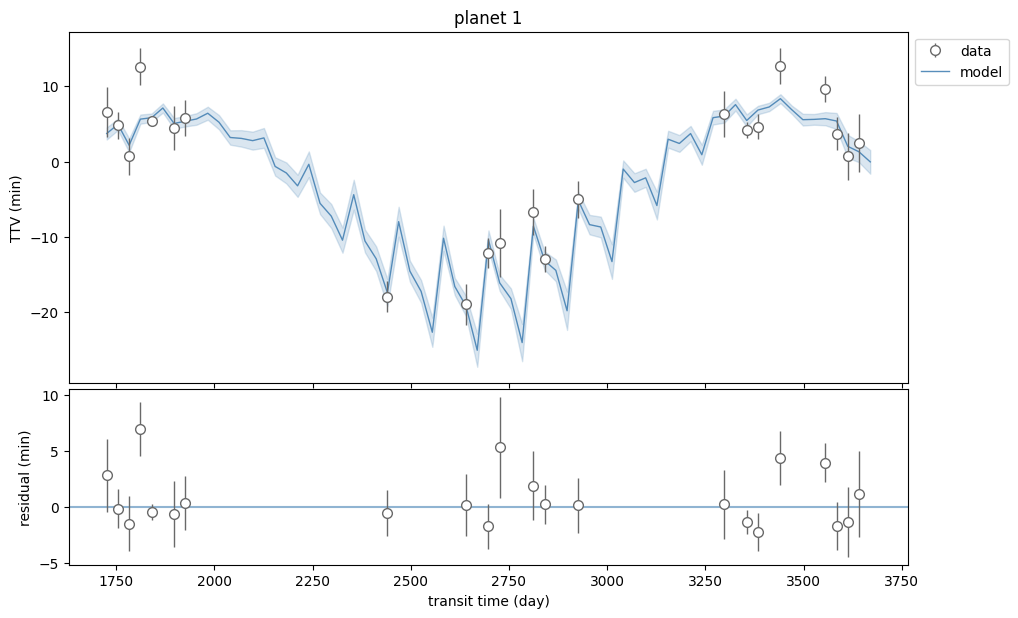

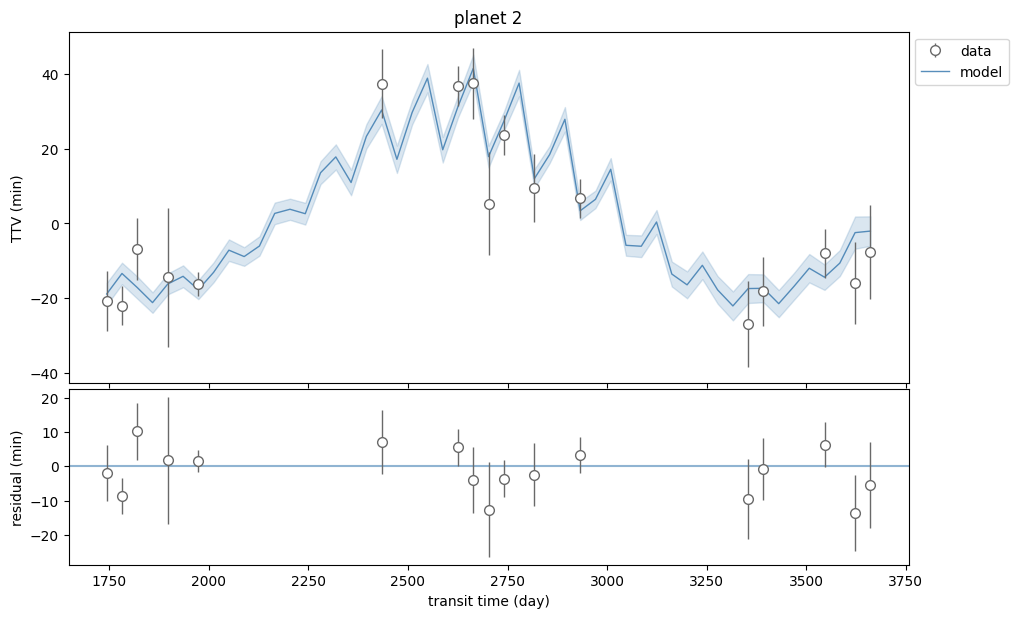

In [23]:
jttv.plot_model(means, tcmodelunclist=stds)

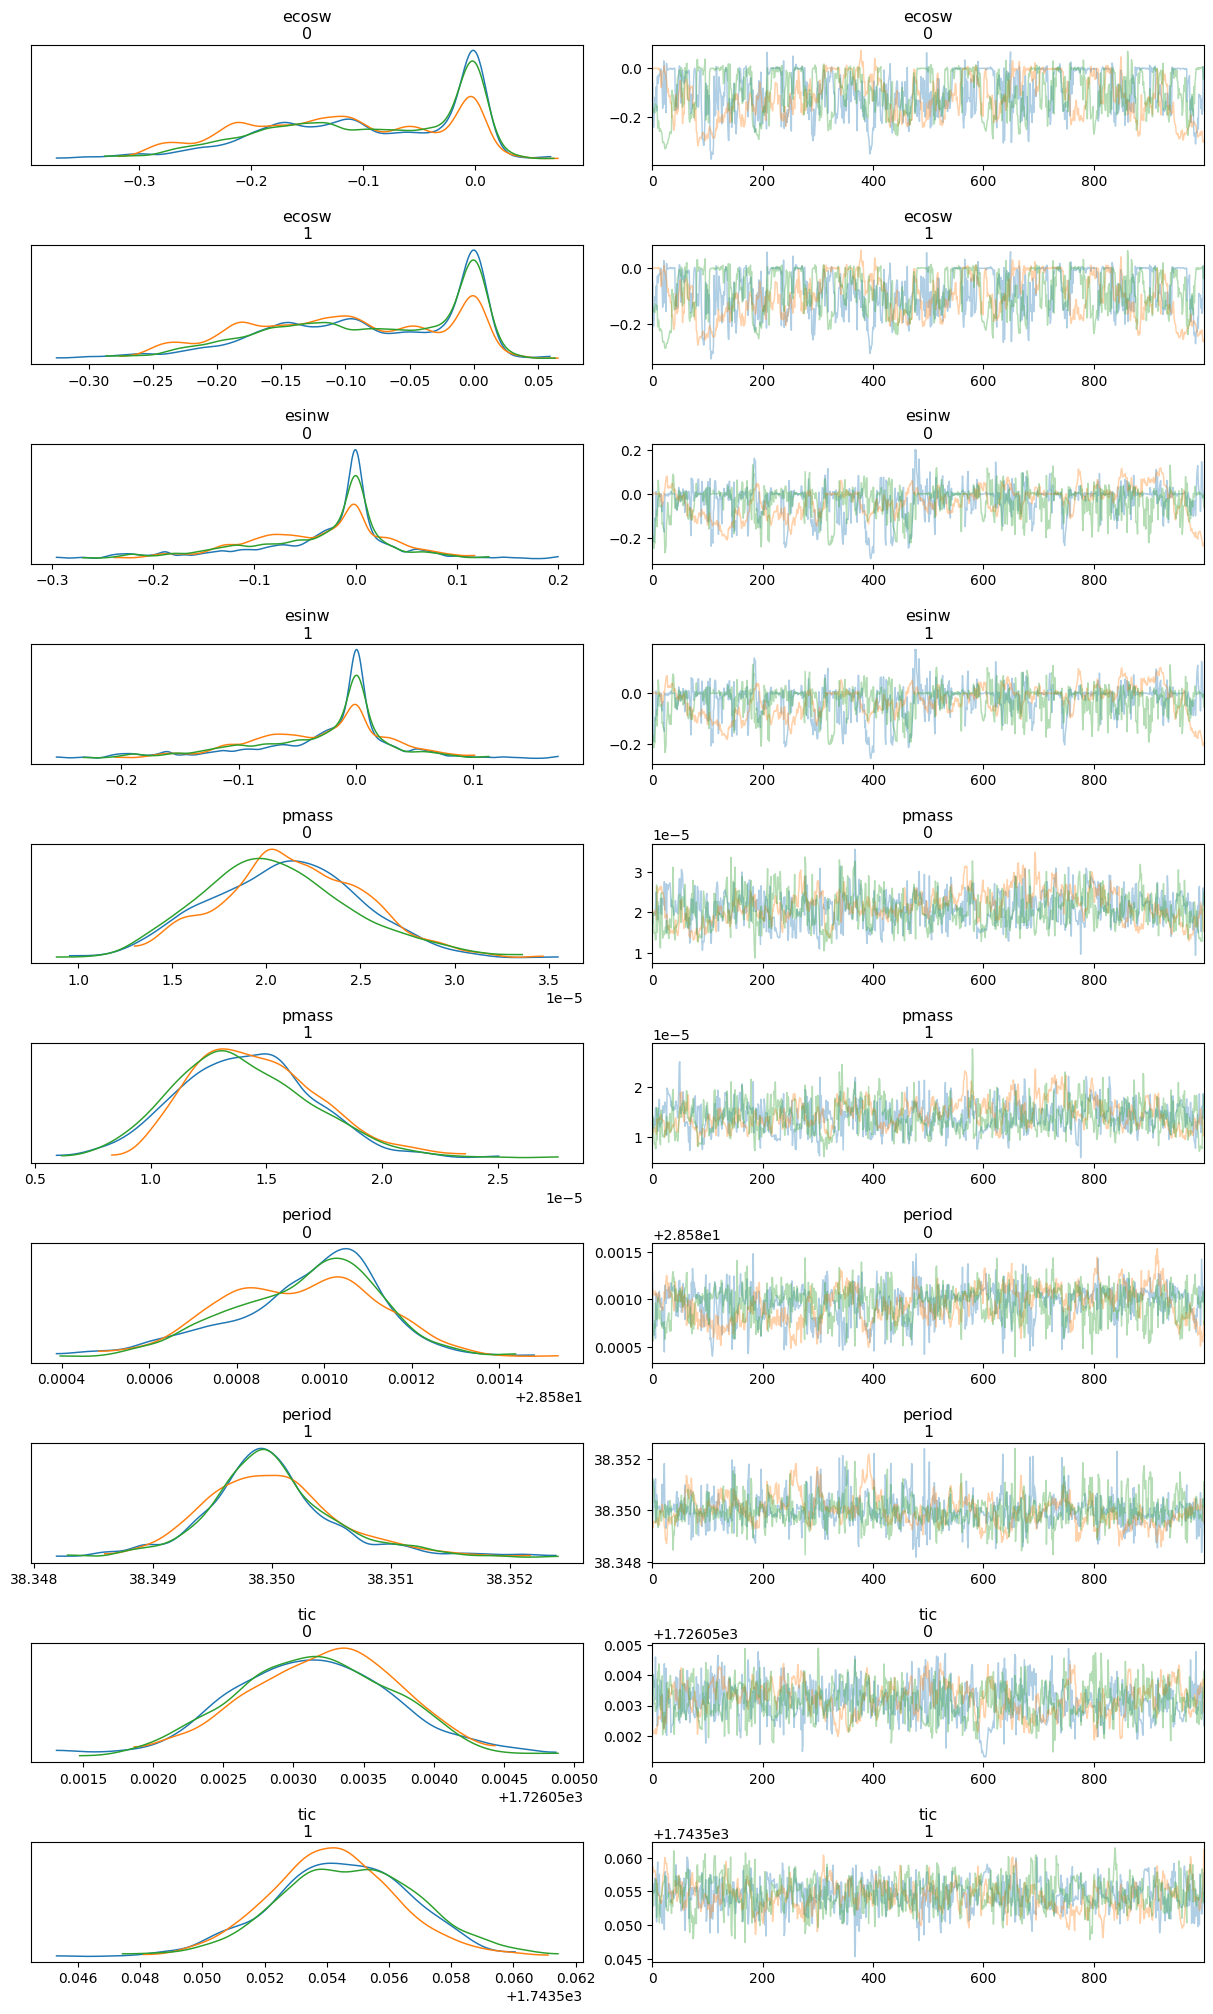

In [24]:
### remove outlie
good=[1,2,3]
az.summary(idata, var_names=sample_keys)
# Drop chain 1 from all groups that have 'chain' as a dimension
idata_filtered = idata.sel(chain=[c for c in idata.posterior.chain.values if c != 1 & c != 0])
az.plot_trace(idata_filtered, var_names=sample_keys, compact=False)
plt.tight_layout(pad=0.2)

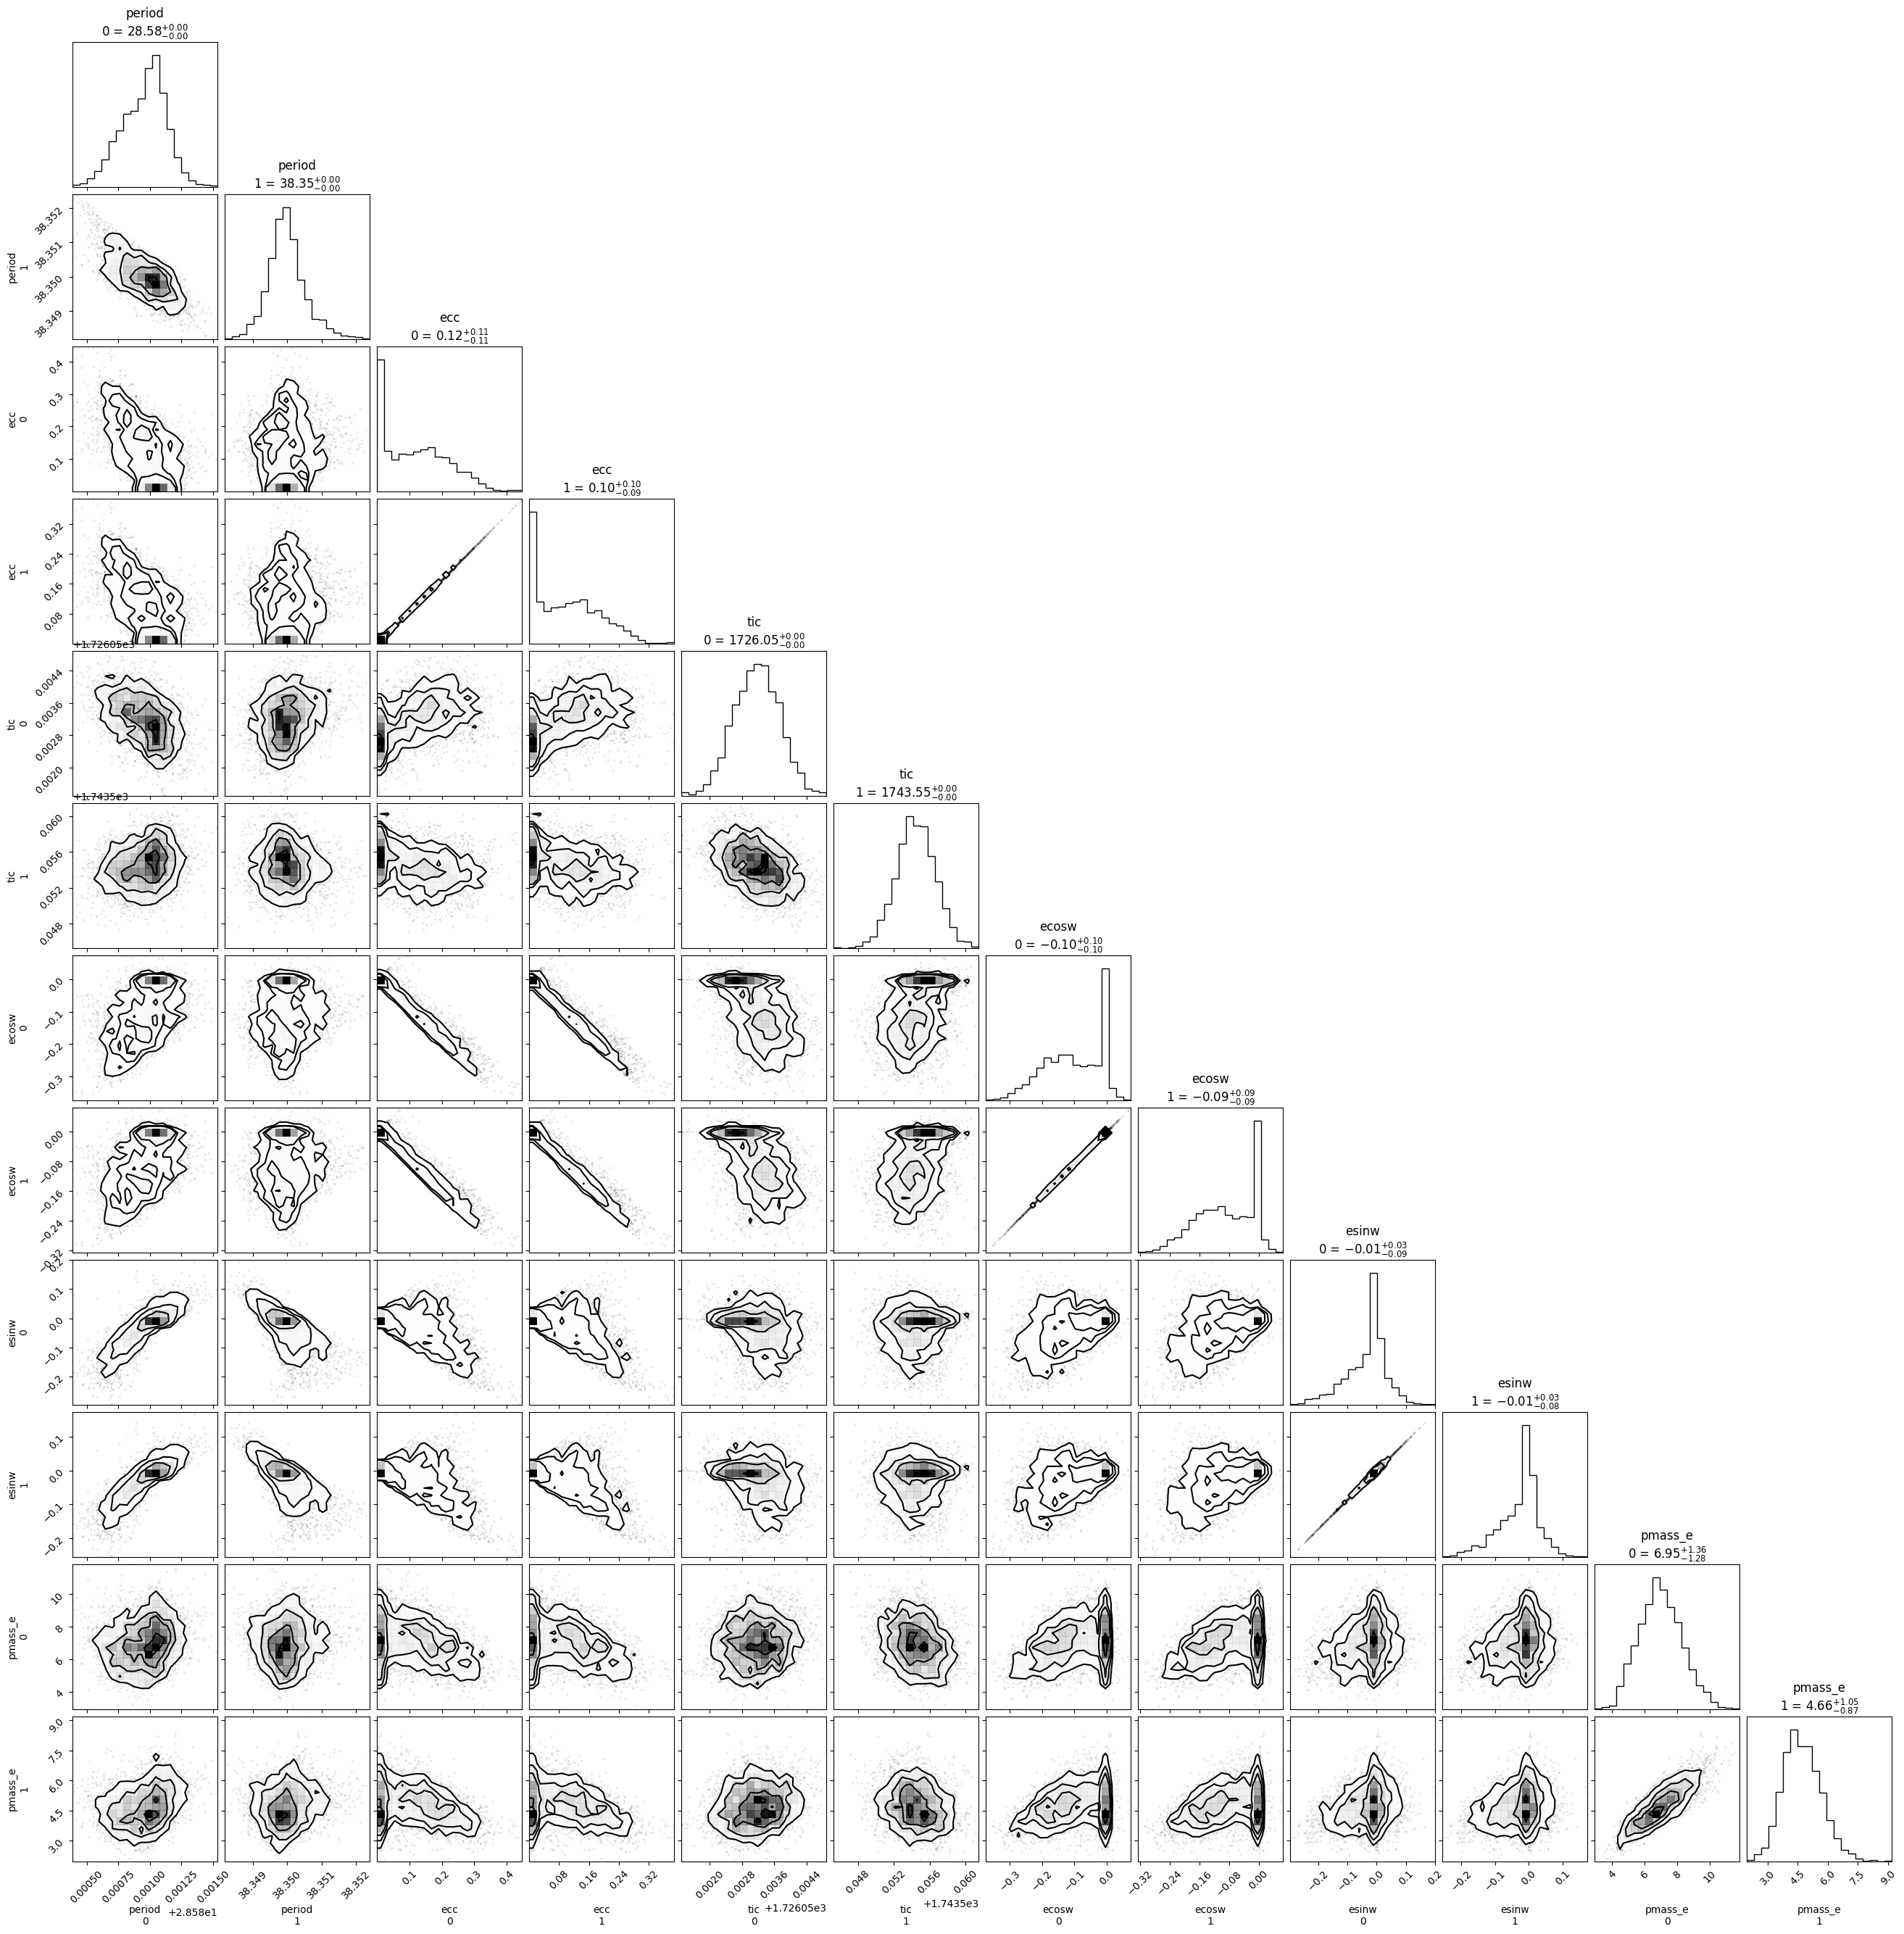

In [25]:
idata_filtered.posterior['pmass_e'] = idata_filtered.posterior['pmass'] / 3.003e-6
names = ["period", "ecc", "tic", "ecosw", "esinw", "pmass_e"]
fig = corner.corner(idata_filtered, var_names=names, show_titles=True)

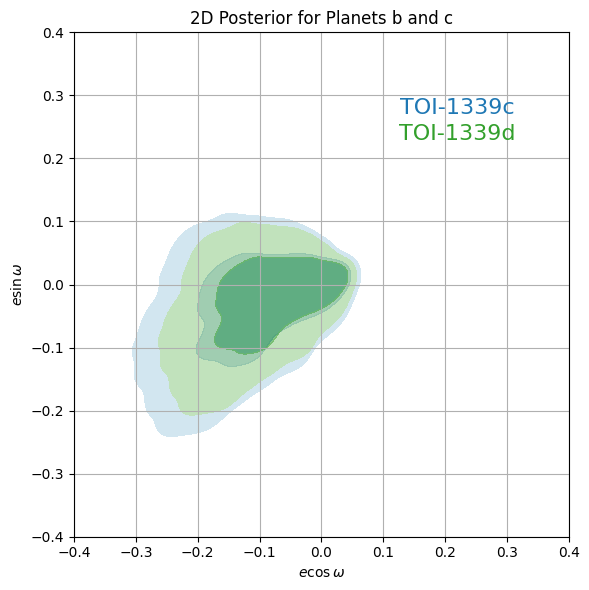

In [26]:
### 2D posterior for ecosw and esinw 
ecosw_b = samples_flat["ecosw"][:, 0]
esinw_b = samples_flat["esinw"][:, 0]

ecosw_c = samples_flat["ecosw"][:, 1]
esinw_c = samples_flat["esinw"][:, 1]

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde


def compute_kde_contour_levels(x, y, gridsize=100):
    data = np.vstack([x, y])
    kde = gaussian_kde(data)
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    X, Y = np.mgrid[x_min:x_max:gridsize*1j, y_min:y_max:gridsize*1j]
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kde(positions).T, X.shape)
    return X, Y, Z, kde

def get_sigma_contour_levels(Z):
    Z_flat = Z.flatten()
    Z_sorted = np.sort(Z_flat)[::-1]
    cumsum = np.cumsum(Z_sorted)
    cumsum /= cumsum[-1]
    levels = []
    for sigma in [0.683, 0.954]:
        idx = np.searchsorted(cumsum, sigma)
        levels.append(Z_sorted[idx])
    return sorted(levels)  # ensures ascending order

# Compute KDEs
Xb, Yb, Zb, kde_b = compute_kde_contour_levels(ecosw_b, esinw_b)
Xc, Yc, Zc, kde_c = compute_kde_contour_levels(ecosw_c, esinw_c)

# Get contour levels
levels_b = get_sigma_contour_levels(Zb)
levels_c = get_sigma_contour_levels(Zc)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Filled contours for planet b (blue shades)
ax.contourf(Xb, Yb, Zb, levels=levels_b + [Zb.max()], colors=['#a6cee3', '#1f78b4'], alpha=0.5)

# Filled contours for planet c (green shades)
ax.contourf(Xc, Yc, Zc, levels=levels_c + [Zc.max()], colors=['#b2df8a', '#33a02c'], alpha=0.5)

# Text annotation
ax.text(0.22, 0.27, 'TOI-1339c', color='#1f78b4', fontsize=16, ha='center')
ax.text(0.22, 0.23, 'TOI-1339d', color='#33a02c', fontsize=16, ha='center')


# Labels and legend
ax.set_xlabel(r"$e \cos\omega$")
ax.set_ylabel(r"$e \sin\omega$")
ax.set_title("2D Posterior for Planets b and c")
blue_patch = plt.Line2D([], [], color='#a6cee3', label='Planet b')
red_patch = plt.Line2D([], [], color='#b2df8a', label='Planet c')
# ax.legend(handles=[blue_patch, red_patch])

plt.grid(True)
plt.xlim(-0.40,0.40)
plt.ylim(-0.40,0.40)
plt.tight_layout()
plt.show()

In [27]:
az.summary(idata_filtered, var_names=["ecc","ecosw_scaled","esinw_scaled", "pmass_scaled","period_scaled","tic_scaled"], round_to=3)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
ecc[0],0.122,0.097,0.000,0.285,0.009,0.004,130.432,288.824,1.025
ecc[1],0.104,0.083,0.000,0.245,0.007,0.003,125.032,288.399,1.026
ecosw_scaled[0],0.401,0.089,0.241,0.519,0.008,0.003,144.531,187.480,1.018
ecosw_scaled[1],0.417,0.077,0.278,0.518,0.007,0.003,144.455,195.158,1.017
esinw_scaled[0],0.471,0.070,0.317,0.588,0.006,0.004,172.603,361.895,1.035
esinw_scaled[1],0.476,0.060,0.344,0.578,0.005,0.003,173.081,361.895,1.035
pmass_scaled[0],0.021,0.004,0.013,0.028,0.000,0.000,121.988,601.285,1.022
pmass_scaled[1],0.014,0.003,0.009,0.020,0.000,0.000,187.417,322.151,1.021
period_scaled[0],0.502,0.000,0.502,0.503,0.000,0.000,231.254,729.559,1.032
period_scaled[1],0.500,0.001,0.498,0.501,0.000,0.000,267.708,488.526,1.022


In [183]:
### posterior samples 
ecosw_b = samples_flat["ecosw"][:, 0]
esinw_b = samples_flat["esinw"][:, 0]
Per_b = samples_flat["period"][:,0] # [days]
Tc_b = samples_flat["tic"][:,0] # [days]
pmass_b = samples_flat["pmass"][:, 0] # [solar mass]

ecosw_c = samples_flat["ecosw"][:, 1]
esinw_c = samples_flat["esinw"][:, 1]
Per_c = samples_flat["period"][:,1] # [days]
Tc_c = samples_flat["tic"][:,1] # [days]
pmass_c = samples_flat["pmass"][:, 1] # [solar mass]

### convert planet mass from solar to earth masses 
import astropy.constants as u
convert = (u.M_sun / u.M_earth).value
pmass_earth_b = pmass_b * convert
pmass_earth_c = pmass_c * convert


# Compute eccentricity and omega (in radians and degrees) for each sample
ecc_b = np.sqrt(ecosw_b**2 + esinw_b**2)
omega_rad_b = np.arctan2(esinw_b, ecosw_b)
omega_deg_b = np.rad2deg(omega_rad_b)

# Compute eccentricity and omega (in radians and degrees) for each sample
ecc_c = np.sqrt(ecosw_c**2 + esinw_c**2)
omega_rad_c = np.arctan2(esinw_c, ecosw_c)
omega_deg_c = np.rad2deg(omega_rad_c)


### keep Omega constant
value_Omega_b = 0  # [deg]
Omega_b = [np.radians(value_Omega_b)] * len(omega_rad_b)  # [rad]
value_Omega_c = 0 # [deg]
Omega_c = [np.radians(value_Omega_c)] * len(omega_rad_c)  # [rad]

pomega_rad_b = omega_rad_b + Omega_b
pomega_rad_c = omega_rad_c + Omega_c


Delta_omega_rad = omega_rad_c - omega_rad_b
Delta_omega_deg = omega_deg_c - omega_deg_b

In [184]:
print(np.median(ecc_b))
print(np.median(omega_rad_b))
print(np.median(ecc_c))
print(np.median(omega_rad_c))

print(np.max(ecc_b))
print(np.min(ecc_c))
print(np.max(omega_rad_b))
print(np.min(omega_rad_b))

0.11000055613090962
-2.269105818346076
0.09280414368696438
-2.0735013704373206
0.45110039425091497
3.0281441753203276e-05
3.1410266056443317
-3.1412858281445417


# Investigate two eccentricity modes

/opt/homebrew/anaconda3/lib/python3.12/site-packages/jnkepler/jaxttv/jaxttv.py:523: UserWarning: using t0 and P from a linear fit to the observed transit times.
  warnings.warn(


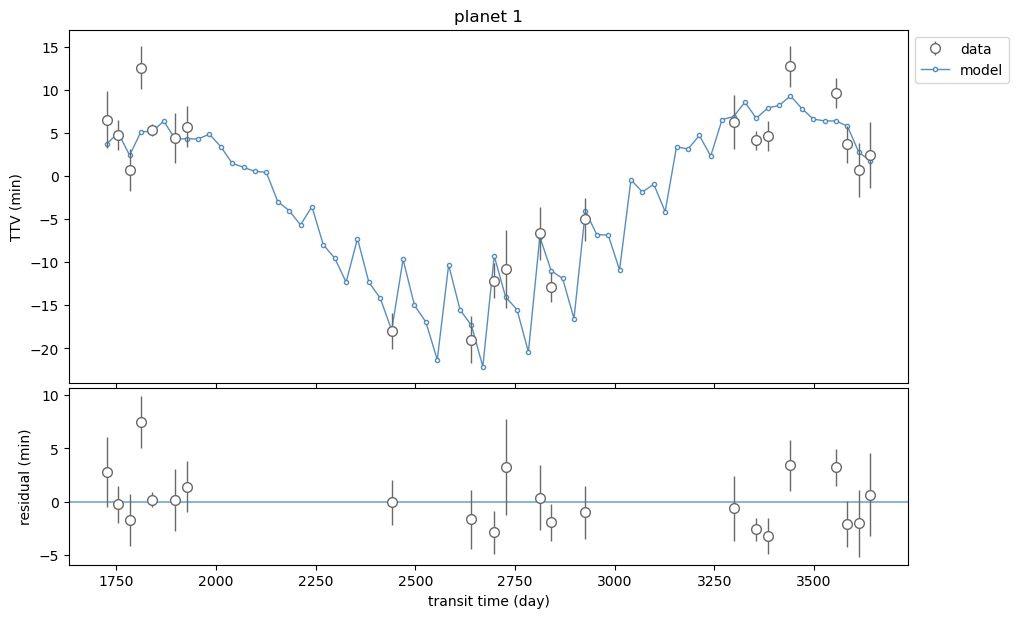

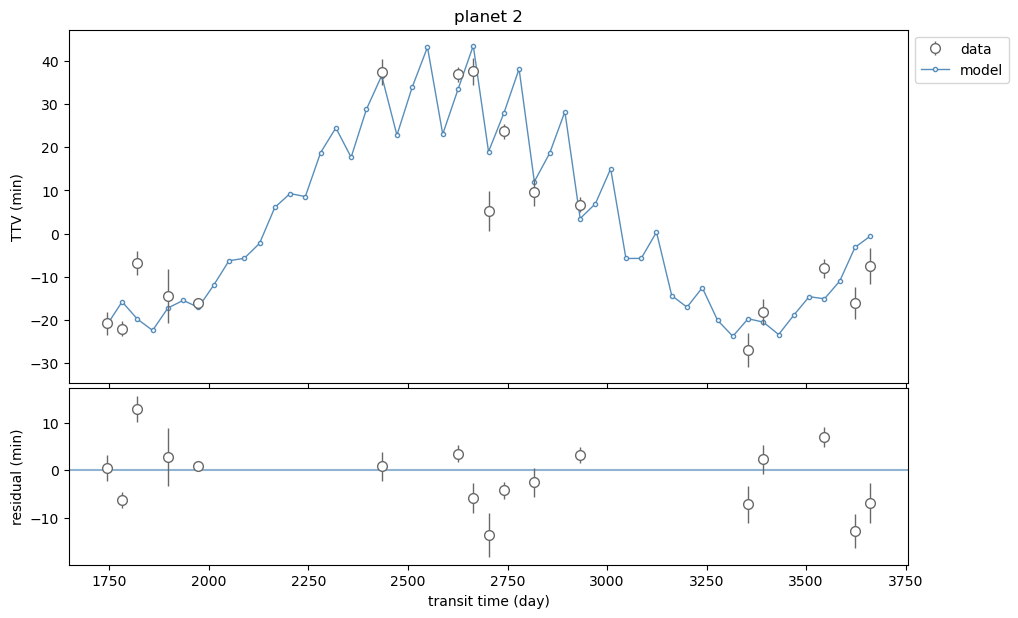

In [29]:
# Your target mode center (e.g., from visual inspection)
target_ecosw = -0.15
target_esinw = -0.17

# Compute distances from each sample
distances = np.sqrt((ecosw_b - target_ecosw)**2 + (esinw_b - target_esinw)**2)

# Find closest sample
closest_idx = np.argmin(distances)

sample_dict = {
    'period': samples_flat['period'][closest_idx],
    'ecosw': samples_flat['ecosw'][closest_idx],
    'esinw': samples_flat['esinw'][closest_idx],
    'tic': samples_flat['tic'][closest_idx],
    'pmass': samples_flat['pmass'][closest_idx],
}
# sample_dict['pmass'] = np.exp(sample_dict['lnpmass'])

tcall = jttv.get_transit_times_all_list(sample_dict)

# Plot the model
jttv.plot_model(tcall, marker='.')
plt.show()

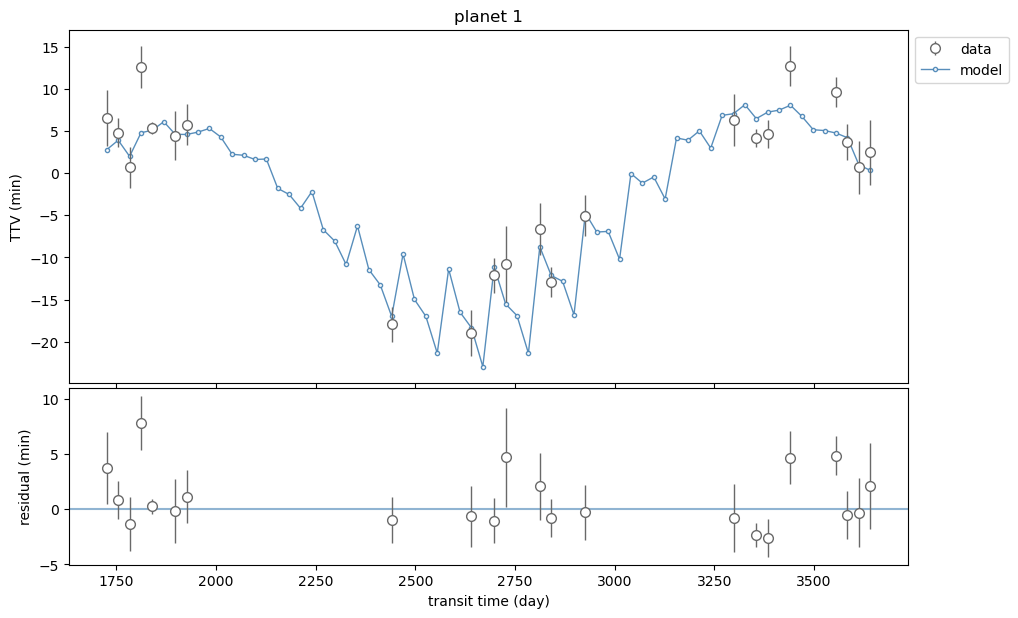

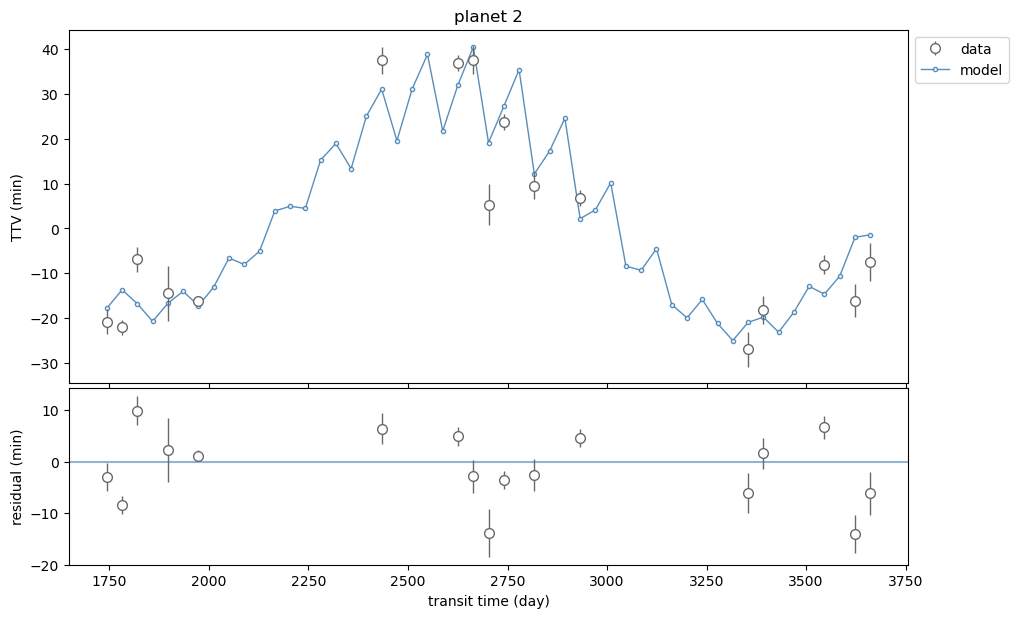

In [30]:
# Your target mode center (e.g., from visual inspection)
target_ecosw = 0.01
target_esinw = 0.01

# Compute distances from each sample
distances = np.sqrt((ecosw_b - target_ecosw)**2 + (esinw_b - target_esinw)**2)

# Find closest sample
closest_idx_2 = np.argmin(distances)

sample_dict = {
    'period': samples_flat['period'][closest_idx_2],
    'ecosw': samples_flat['ecosw'][closest_idx_2],
    'esinw': samples_flat['esinw'][closest_idx_2],
    'tic': samples_flat['tic'][closest_idx_2],
    'pmass': samples_flat['pmass'][closest_idx_2],
}
# sample_dict['pmass'] = np.exp(sample_dict['lnpmass'])

tcall = jttv.get_transit_times_all_list(sample_dict)

# Plot the model
jttv.plot_model(tcall, marker='.')
plt.show()

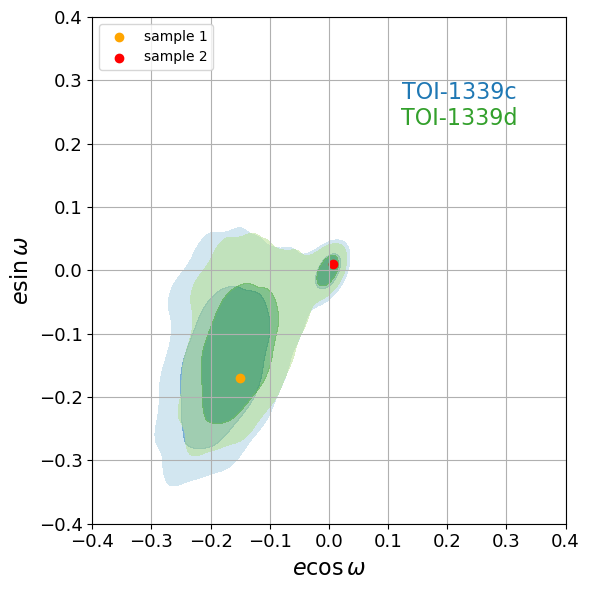

In [48]:
# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Filled contours for planet b (blue shades)
ax.contourf(Xb, Yb, Zb, levels=levels_b + [Zb.max()], colors=['#a6cee3', '#1f78b4'], alpha=0.5)

# Filled contours for planet c (green shades)
ax.contourf(Xc, Yc, Zc, levels=levels_c + [Zc.max()], colors=['#b2df8a', '#33a02c'], alpha=0.5)

# Text annotation
ax.text(0.22, 0.27, 'TOI-1339c', color='#1f78b4', fontsize=16, ha='center')
ax.text(0.22, 0.23, 'TOI-1339d', color='#33a02c', fontsize=16, ha='center')


# Labels and legend
ax.set_xlabel(r"$e \cos\omega$", fontsize=16)
ax.set_ylabel(r"$e \sin\omega$", fontsize=16)
# ax.set_title("2D Joint Posterior of $e  cos(\omega)$ and $e sin(\omega)$")
blue_patch = plt.Line2D([], [], color='#a6cee3', label='Planet b')
red_patch = plt.Line2D([], [], color='#b2df8a', label='Planet c')
# ax.legend(handles=[blue_patch, red_patch])
ax.scatter(ecosw_b[closest_idx],esinw_b[closest_idx], c='orange', label='sample 1')
ax.scatter(ecosw_b[closest_idx_2],esinw_b[closest_idx_2], c='r', label='sample 2')
plt.legend(loc='upper left')
# plt.grid(True)
plt.tick_params(axis='both', labelsize=13) 
plt.xlim(-0.40,0.40)
plt.ylim(-0.40,0.40)
plt.grid(True)
plt.tight_layout()
plt.show()

# Constraints on duration

In [35]:
def dur_ratio(b, e, esinw):
    term1 = np.sqrt(1-b**2)
    term2_num = np.sqrt(1-e**2)
    term2_den = 1 + esinw
    term2 = term2_num / term2_den
    dur_rat = term1 * term2
    return dur_rat
    

In [36]:
### from lubin 2022
b_b = 0.63 
b_b_err = 0.02

b_c =  0.48 
b_c_err = 0.04

In [37]:
dur_ratio_b = dur_ratio(b_b, ecc_b, esinw_b)
dur_ratio_c = dur_ratio(b_c, ecc_c, esinw_c)


In [38]:
print(dur_ratio_b)
print(dur_ratio_c)

[1.01419828 0.87935602 0.90827896 ... 0.73530167 0.80593084 0.90744429]
[1.10636357 0.97725213 1.0057392  ... 0.83672943 0.9054128  1.00668317]
